Collegamento al file CSS utilizzato.

In [318]:
from IPython.core.display import HTML

def css_styling():
    styles = open("custom.css", "r").read()
    return HTML(styles)

css_styling()

## IMPORTAZIONE LIBRERIE E SETTAGGI DEI GRAFICI

In [317]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# impostazione stile grafici
# palette di colori, divisione della palette "Paired"
colori_soft=['#cab2d6', '#fdbf6f', '#b2df8a', '#a6cee3', '#ffff99', '#fb9a99']
colori_strong=['#6a3d9a', '#ff7f00', '#33a02c', '#1f78b4', '#b15928', '#e31a1c']
colori = colori_strong + colori_soft
## stile, scala delle griglia, dimensioni, palette default
sns.set(style="whitegrid",font_scale=1.3, rc={'figure.figsize':(8,6)}, palette=colori)

display(sns.color_palette(colori_soft))
sns.color_palette(colori_strong)

[(0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (1.0, 1.0, 0.6),
 (0.984313725490196, 0.6039215686274509, 0.6)]

[(0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 0.4980392156862745, 0.0),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745)]

# HBL 7 Seasons Statistics

Origine dataset: __[Kaggle - Bundes Handball 7 Seasons](https://www.kaggle.com/datasets/javierandresmansilla/bundes-handball-7-seasons-until-half-2024)__

Informazioni originali raccolte dal sito __[HBL.DE](https://www.liquimoly-hbl.de/)__

Il dataset contiene le informazioni relative al campionato tedesco nazionale di prima e seconda categoria di pallamano.<br>
Le stagione considerate sono dalla stagione 17-18 alla stagione 23-24 (quest'ultima non era terminata quando è stato creato il dataset).<br>
L'ultimo aggiornamento del dataset risale a due anni fa.

Il dataset contiene 5825 righe e 20 colonne, dove ogni riga comprende le statistiche di un dato giocatore in una specifica stagione.<br>
Uno stesso giocatore (Nome, Cognome) può apparire più volte, una volta per ogni stagione giocata con le relative statistiche.

#### COLONNE DEL DATASET

| Nome originale | Nome tradotto | Descrizione |
| :- | :- | :- |
| Lastname | Cognome | Cognome del giocatore |
| Name | Nome | Nome del giocatore |
| Team | Squadra | Nome della squadra con cui gioca per la stagione corrente |
| Position | Posizione | Ruolo del giocatore in campo { GK (Portiere), LB (Terzino Sinistro), CB (Centrale), RB (Terzino Destro), P (Pivot), LW (Ala Sinistra), RW (Ala Destra) } |
| Games Played | Partite Giocate | Numero delle partite giocate durante la stagione |
| Goals | Gol Totali | Numero totale di reti effettuate in tutta la stagione |
| Missed | Tiri Sbagliati | Numero di tiri sbagliati effettuati in tutta la stagione |
| Field Goals | Gol Azione | Numero di reti effettuate con un'azione di gioco |
| Penalty Goals | Gol Rigore | Numero di reti effettuate con un tiro di rigore |
| Shooting Accuracy | Percentuale Realizzazione | Percentuale di realizzazione di gol per la stagione in corso, calcolata come [ Gol Totali / (Gol Totali + Tiri Sbagliati) ] |
| Assists | Assist | Numero di assist terminati con un gol per la stagione corrente |
| Technical Faults | Falli Tecnici | Numero di falli tecnici recevuti | 
| Steals | Intercetti | Numero di palloni intercettati durante la stagione |
| Blocks | Blocchi | Numero di blocchi effettuati |
| Yellow Cards | Cartellino Giallo | Numero di cartellini gialli ricevuti durante la stagione |
| 2 Min Exclusion | 2 Minuti | Numero di esclusioni da 2 minuti ricevute durante la stagione |
| Red Cards | Cartellino Rosso | Numero di cartellini rossi ricevuti durante la stagione |
| Blue Cards | Cartellino Blu | Numero di cartellini blu ricevuti durante la stagione |
| Season | Stagione | Nome della stagione corrente |
| Tier | Categoria | Categoria di cui fa parte il giocatore {A, B} |
| - | Tiri Totali | Tiri totali effettuati nel corso della stagione, calcolato (Gol Totali + Tiri Sbagliati) |

Caricamento del dataset dal file _"csv"_

In [221]:
hbl = pd.read_csv('csv/men_hbl_7_seasons_stats.csv', encoding='utf8')
hbl.head()

,Lastname,Name,Team,Position,Games Played,Goals,Missed,Field Goals,Penalty Goals,Shooting Accuracy,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards,Season,Tier
0,Savvas,Savvas,HIL,LB,36,289,195,210,79,0.5971,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,38,275,93,163,112,0.7473,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,RB,37,258,141,178,80,0.6466,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,LB,35,251,194,142,109,0.5640,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,RW,37,243,98,132,111,0.7126,24,29,20,0,4,2,0,0,17/18,B


In [222]:
# nomi delle colonne originali
hbl.columns

Index(['Lastname', 'Name', 'Team', 'Position', 'Games Played', 'Goals',
       'Missed', 'Field Goals', 'Penalty Goals', 'Shooting Accuracy',
       'Assists', 'Technical Faults', 'Steals', 'Blocks', 'Yellow Cards',
       '2 Min Exclusion', 'Red Cards', 'Blue Cards', 'Season', 'Tier'],
      dtype='object')

Traduzione nomi delle colonne

In [223]:
nomi_colonne = ['Cognome', 'Nome', 'Squadra', 'Posizione', 'Partite Giocate', 'Gol Totali', 'Tiri Sbagliati', 'Gol Azione', 'Gol Rigore', 'Percentuale Realizzazione',
                'Assist', 'Falli Tecnici', 'Intercetti', 'Blocchi', 'Cartellino Giallo', '2 Minuti', 'Cartellino Rosso', 'Cartellino Blu', 'Stagione', 'Categoria']

hbl = hbl.set_axis(axis=1, labels=nomi_colonne)
hbl.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,Percentuale Realizzazione,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
0,Savvas,Savvas,HIL,LB,36,289,195,210,79,0.5971,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,38,275,93,163,112,0.7473,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,RB,37,258,141,178,80,0.6466,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,LB,35,251,194,142,109,0.5640,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,RW,37,243,98,132,111,0.7126,24,29,20,0,4,2,0,0,17/18,B


Controlliamo i valori presenti nelle colonne per verificare se ci sono valori da convertire, mappare o tradurre.

In [224]:
for c in hbl.columns:
    print(c)
    print(hbl[c].unique() )
    print('-----')

Cognome
['Savvas' 'Gunnarsson' 'Smits' ... 'Servos' 'Szymon' 'Mestrovic']
-----
Nome
['Savvas' 'Arnor Thor' 'Kay' 'Paul' 'Florian' 'Dirk' 'Merten' 'Christian'
 'Jasper' 'Tobias' 'Alexander' 'Vincent' 'Tom' 'Matthias' 'Lars' 'Gregor'
 'Patrick' 'Julius' 'Dennis' 'Evgeny' 'Gerdas' 'Jerome' 'Robin' 'Daniel'
 'Marc' 'Soren' 'Christoph' 'Jonas' 'Vyron' 'Steffen' 'Nikolaos' 'Jan'
 'Linus' 'Johannes' 'Oddur' 'Pavel' 'Marten' 'Chris' 'Lasse' 'Adrian'
 'Bartosz' 'Bjorn' 'Stefan' 'Jona' 'Kevin' 'Martin' 'Mathias' 'Fabian'
 'Lukas' 'Mindaugas' 'Duncan' 'Noah' 'Benjamin' 'Felix' 'Tomas' 'Eric'
 'Benedikt' 'Tim-Philip' 'Dragan' 'Philip' 'Lutz' 'Jens' 'Philipp' 'Nicky'
 'Antonio' 'Oliver' 'Willy' 'Tim' 'Maciej' 'Richard' 'Romas' 'Julian'
 'Marek' 'Sebastian' 'Libor' 'Marcel' 'Andre' 'Max' 'Falk' 'Christopher'
 'Gabriel' 'Fannar Tor' 'Rickard' 'Roman' 'Dominik' 'Milan' 'Moritz'
 'Yannick' 'Maurice' 'Paco' 'Justin' 'Niklas' 'Pawel' 'Maximilian-Leon'
 'Henning' 'Thees' 'Simen' 'Till' 'Rutger' 'Bengt' '

Mappiamo i valori delle posizioni, il resto non serve convertirlo.

Aggiungiamo una colonna <span class='code-exp'>"Tiri Totali"</span> di cui calcoliamo il valore come la somma tra il contenuto della colonna <span class='code-exp'>"Gol Totali"</span> e <span class='code-exp'>"Tiri Sbagliati"</span>

In [225]:
ruolo = {'GK':'Portiere', 'LB':'Terzino Sinistro', 'CB':'Centrale', 'RB':'Terzino Destro', 'P':'Pivot', 'LW':'Ala Sinistra', 'RW':'Ala Destra'}
hbl['Posizione'] = hbl['Posizione'].map(ruolo)
hbl['Tiri Totali'] = hbl['Gol Totali']+hbl['Tiri Sbagliati']

hbl.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,Percentuale Realizzazione,...,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria,Tiri Totali
0,Savvas,Savvas,HIL,Terzino Sinistro,36,289,195,210,79,0.5971,...,40,7,7,20,16,1,0,17/18,B,484
1,Gunnarsson,Arnor Thor,BHC,Ala Destra,38,275,93,163,112,0.7473,...,17,11,0,2,3,0,0,17/18,B,368
2,Smits,Kay,WHV,Terzino Destro,37,258,141,178,80,0.6466,...,74,20,4,5,10,0,0,17/18,B,399
3,Kaletsch,Paul,KON,Terzino Sinistro,35,251,194,142,109,0.5640,...,62,4,6,13,12,0,0,17/18,B,445
4,Billek,Florian,COB,Ala Destra,37,243,98,132,111,0.7126,...,29,20,0,4,2,0,0,17/18,B,341


Terminiamo riordinando le colonne.

In [226]:
colonne = hbl.columns.tolist()
nuovo_ordine = colonne[0:5] + colonne[-1:] + colonne[5:-1]
hbl = hbl[nuovo_ordine]

hbl.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
0,Savvas,Savvas,HIL,Terzino Sinistro,36,484,289,195,210,79,...,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,Ala Destra,38,368,275,93,163,112,...,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,Terzino Destro,37,399,258,141,178,80,...,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,Terzino Sinistro,35,445,251,194,142,109,...,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,Ala Destra,37,341,243,98,132,111,...,24,29,20,0,4,2,0,0,17/18,B


Salvataggio del dataset modificato.

In [227]:
hbl.to_csv('csv/men_hbl_7_seasons_stats_modificato.csv', index=False)

Ricarichiamo il file appena salvato per controllare che sia stato esportato correttamente.

In [228]:
hbl = pd.read_csv("csv/men_hbl_7_seasons_stats_modificato.csv")
hbl.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
0,Savvas,Savvas,HIL,Terzino Sinistro,36,484,289,195,210,79,...,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,Ala Destra,38,368,275,93,163,112,...,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,Terzino Destro,37,399,258,141,178,80,...,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,Terzino Sinistro,35,445,251,194,142,109,...,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,Ala Destra,37,341,243,98,132,111,...,24,29,20,0,4,2,0,0,17/18,B


<hr>

Definizione variabili d'ambiente

In [303]:
Posizioni = sorted(list(hbl['Posizione'].unique()))
PosNoPortiere = sorted(list(hbl[hbl['Posizione']!='Portiere']['Posizione'].unique()))
Categorie = sorted(list(hbl['Categoria'].unique()))
Stagioni = list(hbl['Stagione'].unique())
Fasce = ["Centro", "Destra", "Sinistra"]

<hr>

*Definizione funzioni*

In [230]:
# Estazione del valore massimo per categoria e stagione
# del valore 'val' passato al datafram 'df'
def estrazione_info_max(df, val):
    df_finale = pd.DataFrame()
    
    for cat in Categorie :
        mc = df['Categoria']==cat
        for stag in Stagioni:
            ms = df[mc]['Stagione']==stag
            df_tmp = df[mc][ms].nlargest(1, val, keep='all')
            df_finale = pd.concat([df_finale, df_tmp])

    return df_finale

In [231]:
# estrae i valori 'val' in base alla funzione 'func' {min, max, mean, sum, ...}
# restituisce i prima n valori più grandi, in caso di pareggio restituisce entrambi i valori
def estrai_valori(val, func, n):
    m = hbl['Posizione'] != 'Portiere'
    df = pd.DataFrame(hbl[m].groupby(['Categoria', 'Cognome', 'Nome'])[val].apply(func)).reset_index()
    df_tmp = pd.concat([ df[df['Categoria']=='A'].nlargest(n, val, keep='all'),
                         df[df['Categoria']=='B'].nlargest(n, val, keep='all') ])
    return pd.merge( df_tmp, hbl.groupby(['Categoria', 'Cognome', 'Nome'])['Percentuale Realizzazione'].mean(),
                     how='left', on=['Categoria', 'Cognome', 'Nome'] );

Codice per estrarre i valori più piccoli

<span class='code-exp'>
df_tmp2 = pd.concat([ df[df['Categoria']=='A'].nsmallest(n, val, keep='first'), df[df['Categoria']=='B'].nsmallest(n, val, keep='first') ]) <br>
df_tmp = pd.concat( [df_tmp1, df_tmp2] )
</span>

<hr>

# ANALISI DEL DATASET

### OSSERVAZIONI GENERALI

Statistiche sulle **partite giocate** per ogni stagione considerando tutti i giocatori.

In [232]:
df_presenze = hbl.groupby(['Stagione','Categoria'])['Partite Giocate'].agg(['min', 'max', 'mean'])
df_presenze

min  max       mean
Stagione Categoria                     
17/18    A            1   34  23.880829
         B            1   38  25.109415
18/19    A            1   34  23.653944
         B            1   38  25.666667
19/20    A            1   29  19.889488
         B            1   24  17.382749
20/21    A            1   38  26.183445
         B            1   36  25.050847
21/22    A            1   34  21.344749
         B            1   38  24.916667
22/23    A            1   35  22.234597
         B            1   38  23.806186
23/24    A            1   31  20.730392
         B            1   31  20.804878

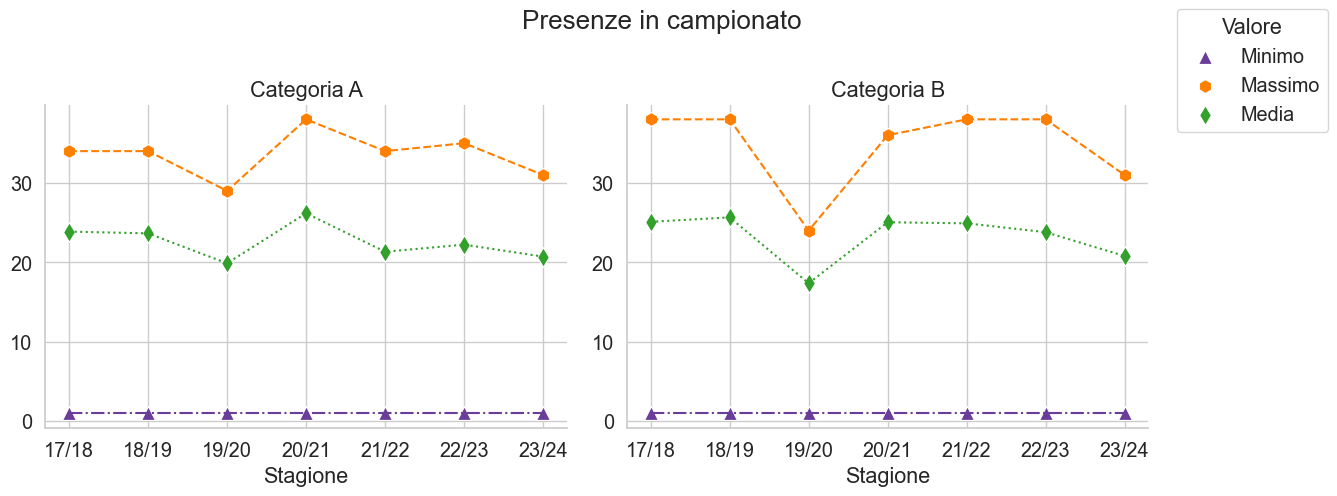

In [233]:
g = sns.FacetGrid( df_presenze.reset_index(), col='Categoria', col_order=Categorie, hue='Categoria', height=5, aspect=1.2,
                  sharey=False, sharex=True, legend_out=True)

def plot_min(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, color=colori_strong[0], marker='^', s=100,label='Minimo' )
    plt.plot(x, y, color=colori_strong[0], linestyle='-.')

def plot_max(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, color=colori_strong[1], marker='h', s=100, label='Massimo')
    plt.plot(x, y, color=colori_strong[1], linestyle='--')

def plot_mean(x, y, **kwargs):
    sns.scatterplot(x=x, y=y, color=colori_strong[2], marker='d', s=100, label='Media')
    plt.plot(x, y, color=colori_strong[2], linestyle=':')

g.map(plot_min, 'Stagione', 'min');
g.map(plot_max, 'Stagione', 'max');
g.map(plot_mean, 'Stagione', 'mean');

# aggiunta legenda e spostamento sopra i grafici
g.add_legend( loc="upper right", borderaxespad=0.5, ncol=1, frameon=True,
             title='Valore', label_order=['Minimo', 'Massimo', 'Media'] );

# specifica nome assi e titolo grafico
g.set_axis_labels( x_var='Stagione', y_var='', clear_inner=True);
g.set_titles( col_template='Categoria {col_name}');
g.fig.suptitle('Presenze in campionato', y=1)

# parametro per la spaziatura automatica, evita sovrapposizioni
g.tight_layout();

Giocatori considerati i migliori marcatori della stagione, cioè con più gol realizzati durante la stagione.

In [234]:
df_marcatori = estrazione_info_max(hbl.groupby(['Stagione', 'Categoria', 'Cognome', 'Nome', 'Posizione'])['Gol Totali'].max().reset_index(),'Gol Totali')
df_marcatori

,Stagione,Categoria,Cognome,Nome,Posizione,Gol Totali
216,17/18,A,Mortensen,Casper,Ala Sinistra,230
1006,18/19,A,Musche,Matthias,Ala Sinistra,256
1664,19/20,A,Elisson,Bjarki Mar,Ala Sinistra,216
2579,20/21,A,Magnusson,Omar Ingi,Terzino Destro,274
3428,21/22,A,Lindberg,Hans,Ala Destra,242
4351,22/23,A,Mortensen,Casper,Ala Sinistra,234
5098,23/24,A,Gidsel,Mathias,Terzino Destro,248
673,17/18,B,Savvas,Savvas,Terzino Sinistro,289
1526,18/19,B,Spatz,Michael,Ala Destra,254
1996,19/20,B,Billek,Florian,Ala Destra,177


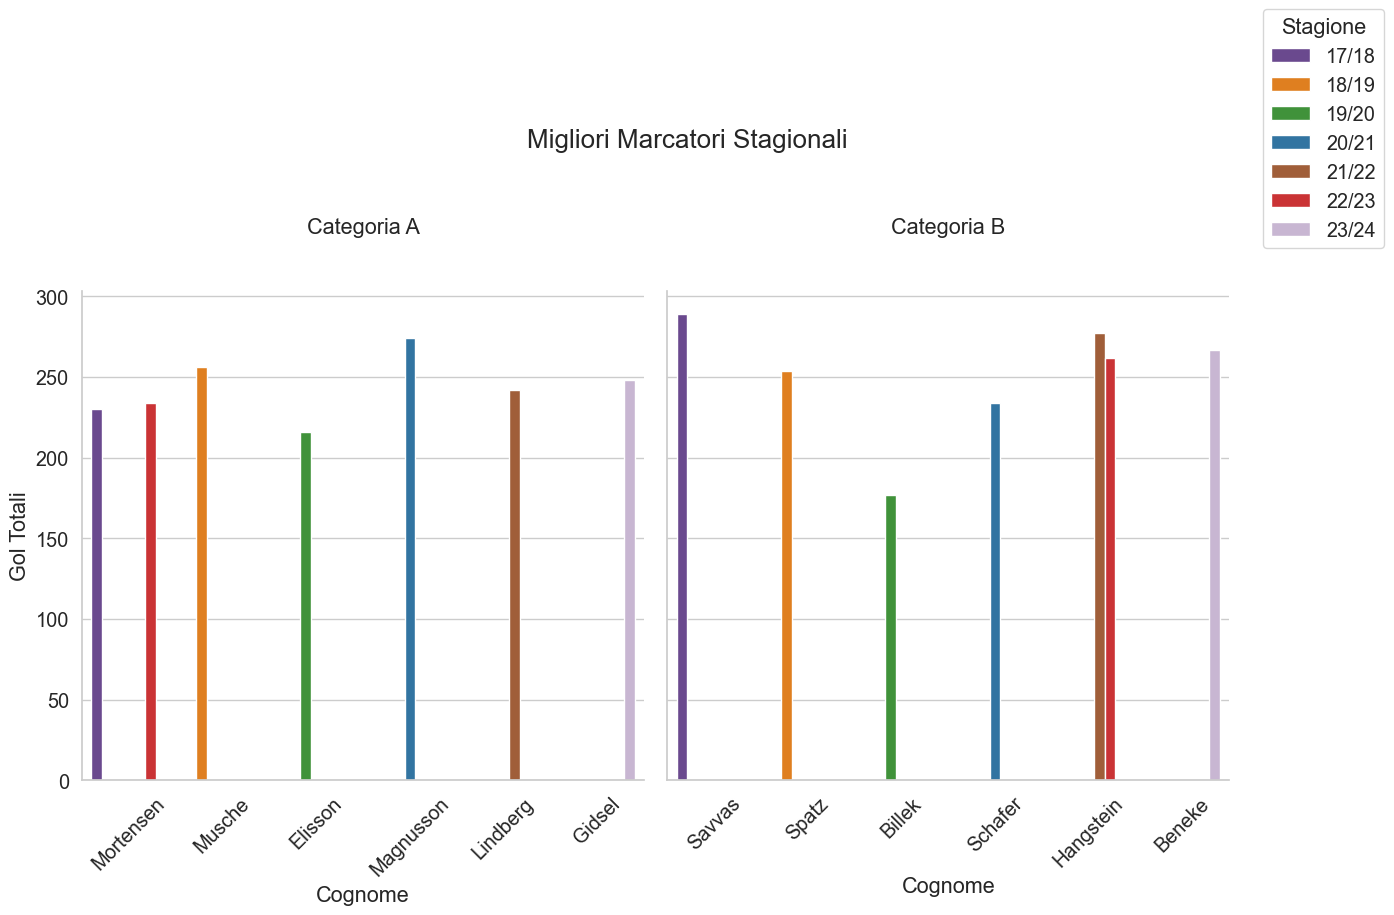

In [235]:
g = sns.catplot(data=df_marcatori, x='Cognome', y='Gol Totali', col='Categoria', hue='Stagione', gap=0,
                kind="bar", height=8, aspect=.8, sharex=False, sharey=True);
g.tick_params(rotation=45, axis='x');

# specifica nome assi e titolo grafico
g.set_titles(col_template='Categoria {col_name}', y=1.1);
g.fig.suptitle('Migliori Marcatori Stagionali', y=1);

# aggiunta legenda e spostamento sopra i grafici
sns.move_legend(g, borderaxespad=0.2, title="Stagione", alignment='center',loc='center right', bbox_to_anchor=(1, 1), ncol=1, frameon=True);

# parametro per la spaziatura automatica, evita sovrapposizioni
g.tight_layout();

Giocatori con la migliore prestazione in difesa.<br>
Ovvero quelli con più <span class='code-exp'>"Falli Tecnici"</span>, questi falli sono quelli consentiti dal gioco che non comportano ammonizioni o espulsioni dal campo.

In [236]:
df_difesa = estrazione_info_max( hbl.groupby(['Stagione', 'Categoria', 'Cognome', 'Nome'])['Falli Tecnici'].max().reset_index(), 'Falli Tecnici' )
df_difesa

,Stagione,Categoria,Cognome,Nome,Falli Tecnici
171,17/18,A,Kuhn,Julius,63
1012,18/19,A,Norouzinezhad Gharehlou,Pouya,53
1147,18/19,A,Weber,Philipp,53
1731,19/20,A,Ivic,Sime,48
2551,20/21,A,Kuhn,Julius,63
2659,20/21,A,Rambo,Christoffer,63
3373,21/22,A,Jeppsson,Simon,61
4146,22/23,A,Casado Marcelo,Agustin,95
5173,23/24,A,Knorr,Juri,85
562,17/18,B,Krings,Merten,77


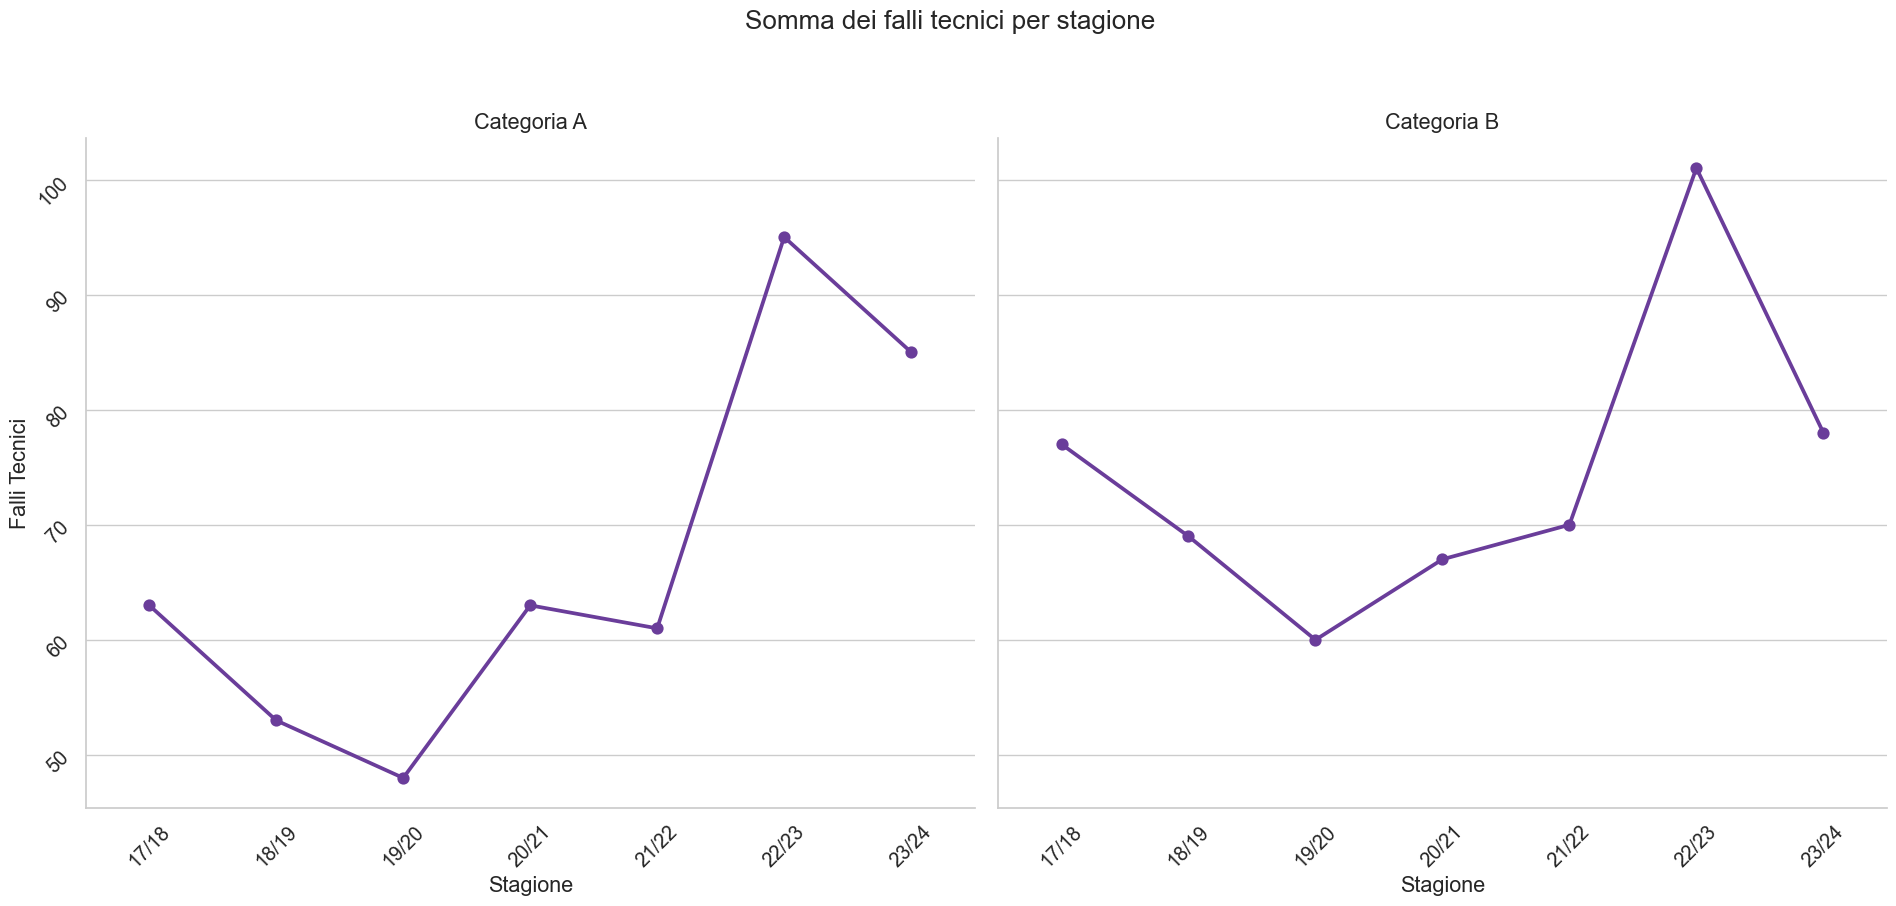

In [280]:
g = sns.FacetGrid( df_difesa, col='Categoria', col_order=Categorie, height=8, aspect=1.2, sharex=True, sharey=True)
g.map( sns.pointplot, 'Stagione', 'Falli Tecnici', order=Stagioni, errorbar=None, marker='o');
g.set_titles( col_template='Categoria {col_name}')
g.tick_params(rotation=45);
g.fig.suptitle('Somma dei falli tecnici per stagione', y=1.1);

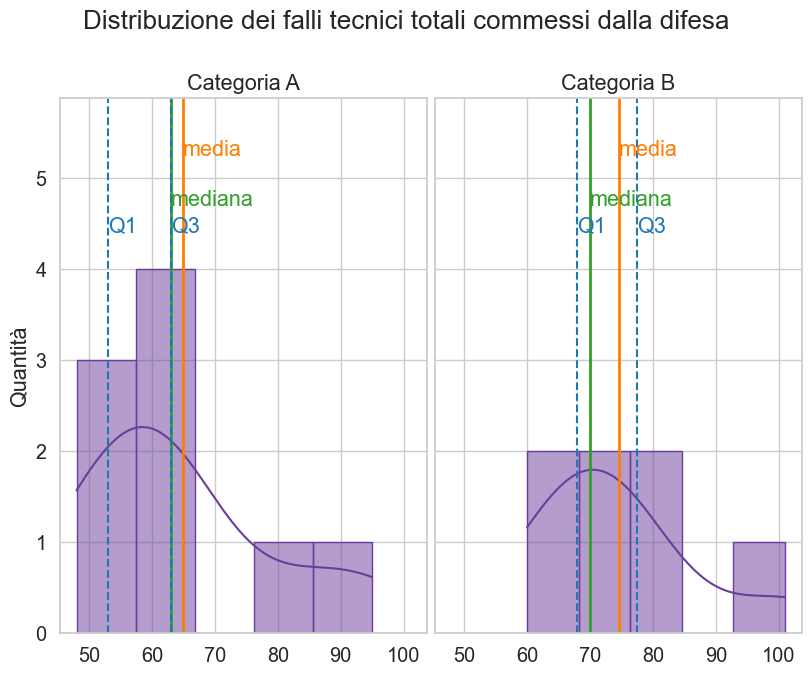

In [285]:
COLORE_MEDIA, COLORE_MEDIANA,COLORE_Q = colori_strong[1], colori_strong[2], colori_strong[3]
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True, squeeze=False, constrained_layout=True)
for ax, c in zip(axes.ravel(), Categorie):
    m = df_difesa['Categoria'] == c
    sns.histplot(df_difesa[m], ax=ax, kde=True, multiple='dodge', edgecolor=colori[0], legend=False);
    ax.set_title(f'Categoria {c}')
    ax.set_ylabel('Quantità');
    ax.autoscale(axis='both', tight=False);
    
    y_lims = ax.get_ylim()
    ax.set_ylim(0, y_lims[1]* 1.4 )
    
    data = df_difesa[m]['Falli Tecnici']
    # valori della MEDIA
    ax.axvline( np.mean(data) , 0, y_lims[1] + 7 , color = COLORE_MEDIA, lw=2) 
    ax.annotate( 'media', xy=(np.mean(data) , y_lims[1] * 1.25), xycoords='data', color = COLORE_MEDIA  )
    # valori della MEDIANA
    ax.axvline( np.median(data) , 0, y_lims[1] + 7, color = COLORE_MEDIANA, lw=2) 
    ax.annotate( 'mediana', xy=(np.median(data) , y_lims[1] * 1.12), xycoords='data', color = COLORE_MEDIANA  )
    # valori dei QUANTILI
    ax.axvline(np.quantile(data, .25) , 0, y_lims[1] + 7, color = COLORE_Q, linestyle = '--') 
    ax.annotate( 'Q1', xy=(np.quantile(data, .25), y_lims[1]*1.05), xycoords='data', color = COLORE_Q  )
    ax.axvline(np.quantile(data, .75) , 0, y_lims[1] + 7, color = COLORE_Q, linestyle = '--') 
    ax.annotate( 'Q3', xy=(np.quantile(data, .75), y_lims[1]*1.05), xycoords='data', color = COLORE_Q  );

fig.suptitle("Distribuzione dei falli tecnici totali commessi dalla difesa", y=1.1);

Precisione al tiro delle squadre che partecipano al campionato durante le diverse stagioni sportive.

In [239]:
df_precisione = hbl.groupby(['Stagione', 'Categoria', 'Squadra'])['Percentuale Realizzazione'].mean().reset_index()
df_precisione

,Stagione,Categoria,Squadra,Percentuale Realizzazione
0,17/18,A,BER,0.450892
1,17/18,A,FAG,0.513921
2,17/18,A,GUM,0.467623
3,17/18,A,GWD,0.447491
4,17/18,A,HAN,0.385308
...,...,...,...,...
258,23/24,B,TUE,0.593582
259,23/24,B,TVG,0.516926
260,23/24,B,TVH,0.417448
261,23/24,B,VFL,0.598520


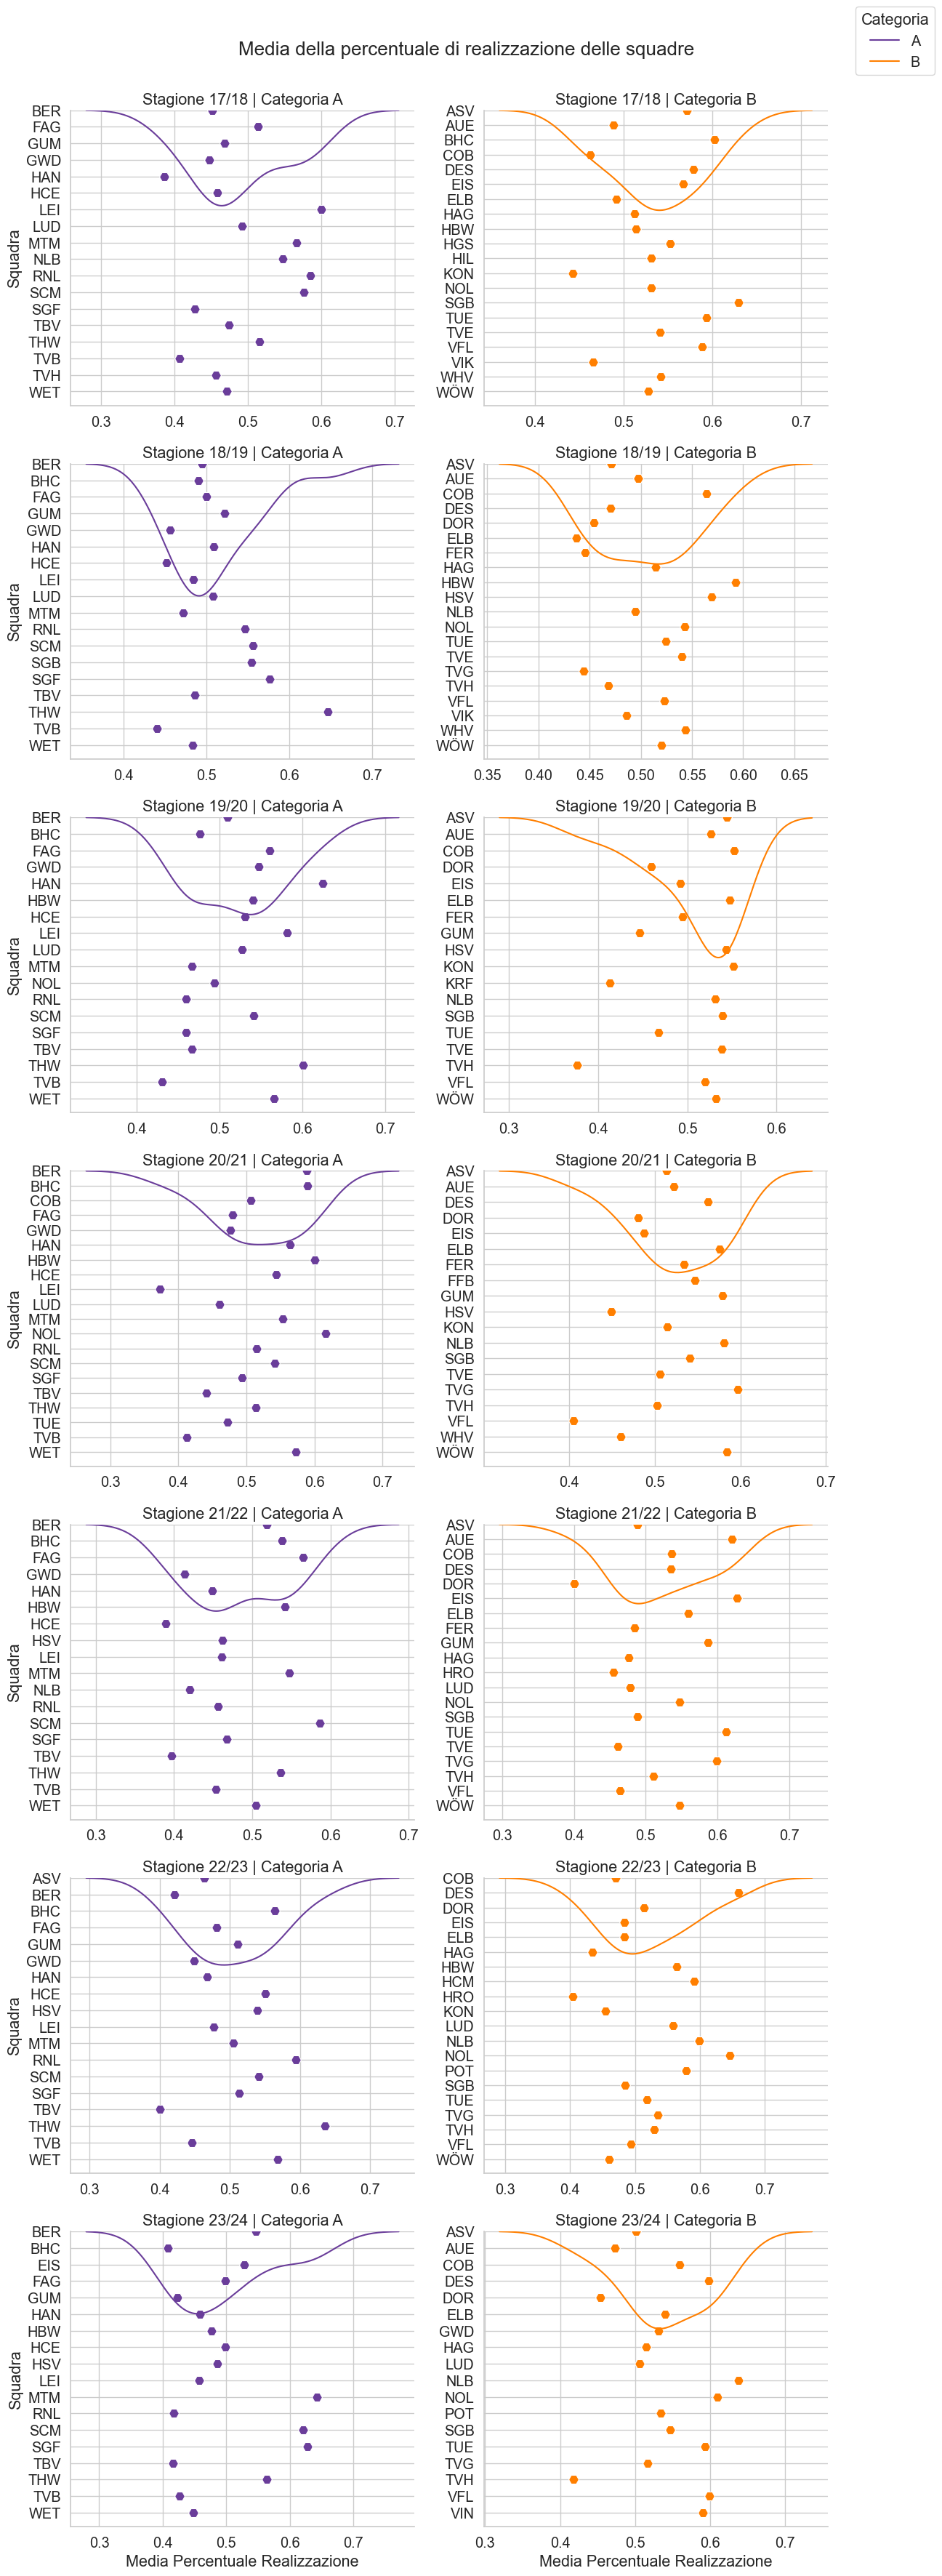

In [240]:
g = sns.FacetGrid( df_precisione, row='Stagione', col='Categoria', sharex=False, sharey=False, height=5, aspect=1.2,
                    hue='Categoria', col_order=Categorie, palette=colori_strong, legend_out=True);
g.map( sns.scatterplot, 'Percentuale Realizzazione', 'Squadra', s=100, marker='H' );
g.map( sns.kdeplot, 'Percentuale Realizzazione');

# specifica nome assi e titolo grafico
g.set_axis_labels( x_var='Media Percentuale Realizzazione', y_var='Squadra', clear_inner=True);
g.set_titles( row_template='Stagione {row_name}', col_template='Categoria {col_name}');
g.fig.suptitle('Media della percentuale di realizzazione delle squadre', y=1);
# aggiunta legenda e spostamento sopra i grafici
g.add_legend(  borderaxespad=0.2, title="Categoria", alignment='center');
sns.move_legend( g, loc='center right', bbox_to_anchor=(1, 1), ncol=1, frameon=True);
# parametro per la spaziatura automatica, evita sovrapposizioni
g.tight_layout();

Quanto ogni posizione contribuisce ai gol fatti e ai tiri sbagliati, distinzione per categoria.

In [314]:
def tiri_pie_plot(cat):
    m = hbl['Categoria']==cat
    # estrazione dei dati
    tiri = hbl[m][['Posizione', 'Gol Totali', 'Tiri Sbagliati']]
    gol = tiri.groupby('Posizione')['Gol Totali'].sum()
    mancati = tiri.groupby('Posizione')['Tiri Sbagliati'].sum()

    # costruzione grafico a torta
    fig, axes = plt.subplots(1, 2, figsize=(10,10), sharex=True, sharey=True, squeeze=False, constrained_layout = True)
    # dizionario con i dati per i grafici
    # { indice : [dataframe, titolo] }
    dati = { 0 : [gol, 'GOL'], 1 : [mancati, 'TIRI SBAGLIATI'] }
    for ax, i in zip(axes.ravel(), dati.keys()):
        ax.pie(x=dati[i][0], labels=Posizioni, autopct='%1.1f%%', explode=[0, 0, .0, 0, .1, 0, 0], pctdistance=0.7, labeldistance=1.1);
        ax.set_title(f'Categoria {cat} - {dati[i][1]} totali realizzati in 7 stagioni', y=1.1);        

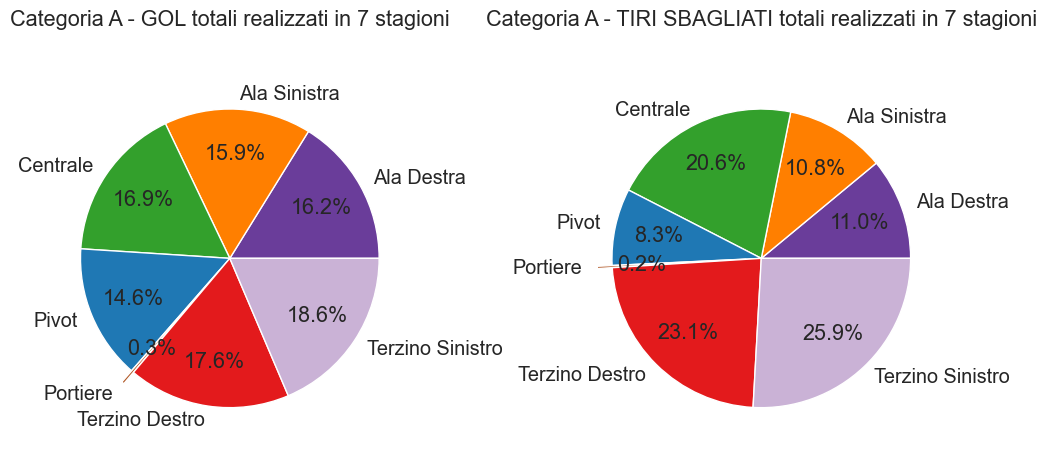

In [315]:
tiri_pie_plot('A')

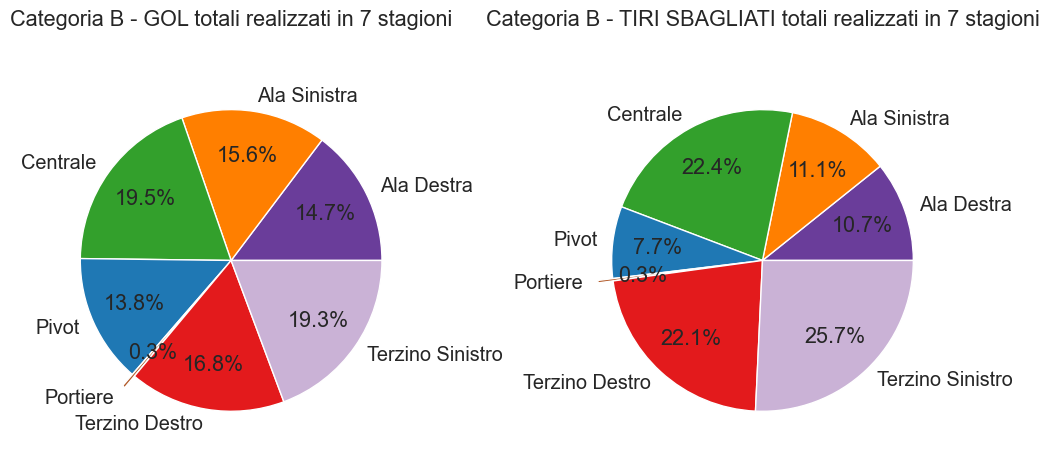

In [316]:
tiri_pie_plot('B')

Focus sui tiri della categoria _'A'_<br>
Osserviamo la tipologia dei tiri in base alla <span class='code-exp'>'Categoria'</span> e <span class='code-exp'>'Posizione'</span>

In [312]:
tiri = hbl[['Posizione', 'Gol Totali', 'Tiri Sbagliati', 'Categoria']]
# calcolo tiri totali
tmp = tiri.groupby(['Categoria','Posizione'])[['Gol Totali', 'Tiri Sbagliati']].sum()
gtA = tmp.loc['A']['Gol Totali'].sum()
tsA = tmp.loc['A']['Tiri Sbagliati'].sum()
gtB = tmp.loc['B']['Gol Totali'].sum()
tsB = tmp.loc['B']['Tiri Sbagliati'].sum()

tiri = tmp.reset_index()
# nuove colonne
tiri[['PercGT', 'PercTS']] = np.NaN
# maschere e df temporanei per il calcolo della percentuale
mA = tiri['Categoria']=='A'
mB = tiri['Categoria']=='B'
tmpA = tiri[mA].copy()
tmpB = tiri[mB].copy()

# calcolo percentuale per le singole categorie
tmpA['PercGT'] = tmpA['Gol Totali'].apply(lambda x: (x / gtA) * 100)
tmpA['PercTS'] = tmpA['Tiri Sbagliati'].apply(lambda x: (x/ tsA) *100)

tmpB['PercGT'] = tmpB.apply(lambda row: (row['Gol Totali'] / gtB) * 100, axis=1)
tmpB['PercTS'] = tmpB.apply(lambda row: (row['Tiri Sbagliati'] / tsB) * 100, axis=1)

# concateno i df per averne uno unico
tiri = pd.concat([tmpA, tmpB])
tiri

,Categoria,Posizione,Gol Totali,Tiri Sbagliati,PercGT,PercTS
0,A,Ala Destra,19004,8043,16.171140,11.010719
1,A,Ala Sinistra,18717,7911,15.926922,10.830014
2,A,Centrale,19841,15046,16.883371,20.597697
3,A,Pivot,17134,6078,14.579894,8.320670
4,A,Portiere,327,177,0.278255,0.242310
5,A,Terzino Destro,20643,16890,17.565820,23.122099
6,A,Terzino Sinistro,21852,18902,18.594598,25.876490
7,B,Ala Destra,19179,8818,14.711658,10.748022
8,B,Ala Sinistra,20309,9076,15.578448,11.062492
9,B,Centrale,25437,18381,19.511989,22.404105


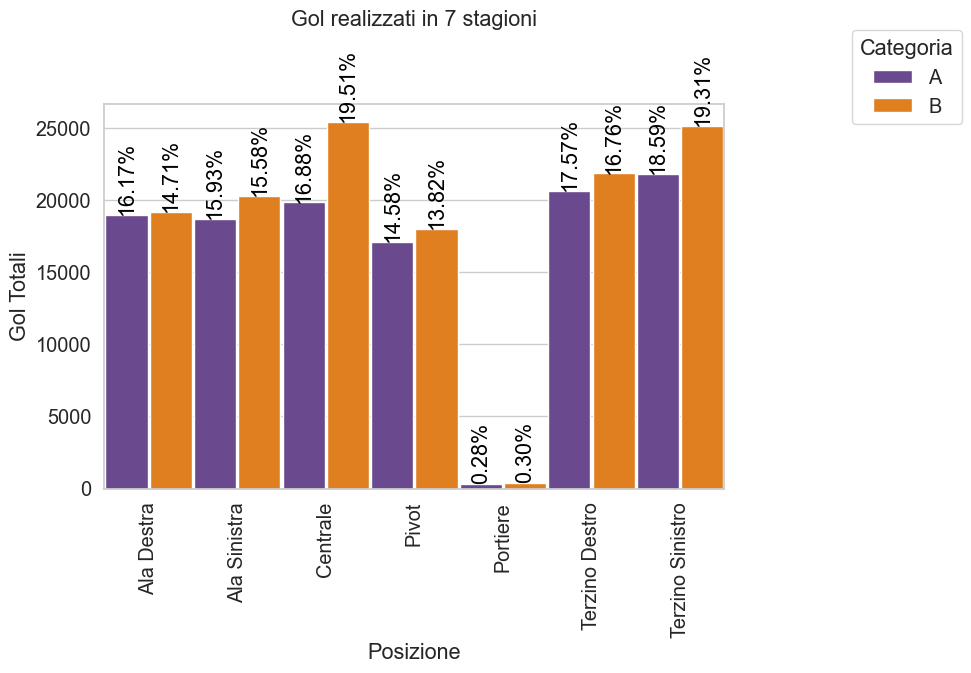

In [313]:
fig = plt.figure( figsize=(8, 5))
sns.barplot(data=tiri, x='Posizione', y='Gol Totali', hue='Categoria', hue_order=Categorie, width=1, gap=.05);
for p in plt.gca().patches:
    larghezza = p.get_width()
    altezza = p.get_height()
    percentuale = tiri.loc[(tiri['Gol Totali'] >= altezza - 0.01) & (tiri['Gol Totali'] <= altezza + 0.01), 'PercGT']
    if not percentuale.empty:
        plt.text(p.get_x() + larghezza / 2, altezza, f"{percentuale.values[0]:.2f}%", ha="center", va="bottom", color='black', rotation=90)

plt.tick_params(axis='x', rotation=90);
plt.legend(borderaxespad=0.2, alignment='center', loc='upper left', bbox_to_anchor=(1.2, 1.2), ncol=1, frameon=True, title='Categoria');

plt.title('Gol realizzati in 7 stagioni', y=1.2, pad=.5);

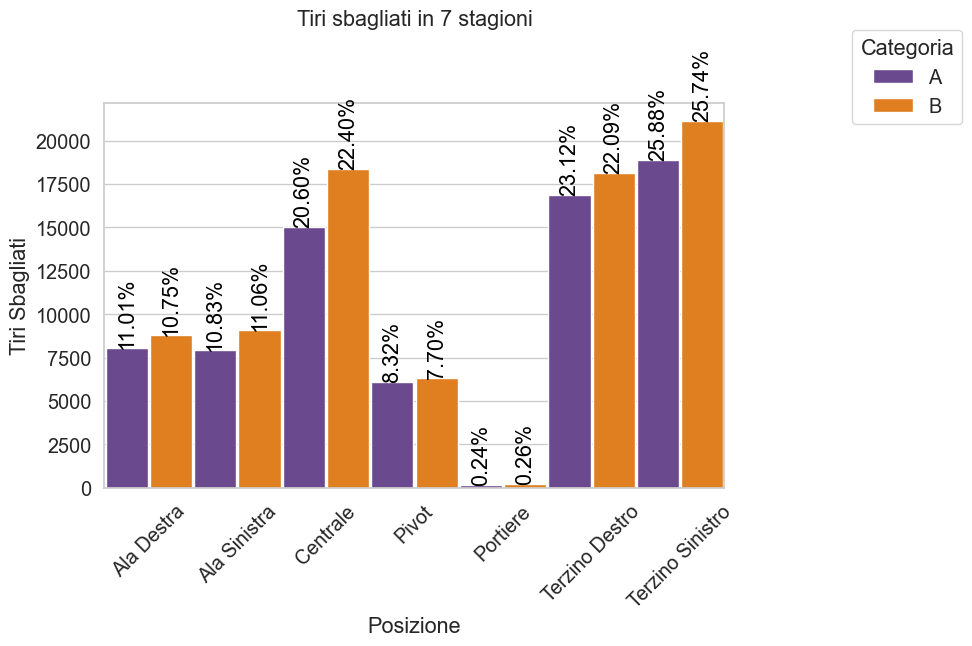

In [246]:
fig = plt.figure( figsize=(8, 5))
sns.barplot(data=tiri, x='Posizione', y='Tiri Sbagliati', hue='Categoria', hue_order=Categorie, width=1, gap=.05, palette=sns.color_palette(colori_strong, 2) );
for p in plt.gca().patches:
    larghezza = p.get_width()
    altezza = p.get_height()
    percentuale = tiri.loc[(tiri['Tiri Sbagliati'] >= altezza - 0.01) & (tiri['Tiri Sbagliati'] <= altezza + 0.01), 'PercTS']
    if not percentuale.empty:
        plt.text(p.get_x() + larghezza / 2, altezza, f"{percentuale.values[0]:.2f}%", ha="center", va="bottom", color='black', rotation=90)

plt.tick_params(axis='x', rotation=45);
plt.legend(borderaxespad=0.2, alignment='center', loc='upper left', bbox_to_anchor=(1.2, 1.2), ncol=1, frameon=True, title='Categoria');

plt.title('Tiri sbagliati in 7 stagioni', y=1.2, pad=.5);

### FOCUS: VISIONE DI GIOCO

La visione di gioco di un giocatore è molto importante, sopratutto se questo è un centrale o un terzino perché dovrebbe essere in grado di vedere tutto quello che succede davanti a se.

Gli *assist* permettono di mandare al tiro un altro giocatore.<br>
Il passaggio deve essere preciso e deve avere il tempismo giusto.

Gli *intercetti* permettono alla squadra in difesa di fare un contropiede, ovvero una ripresa veloce che vede un giocatore solo contro il portiere oppure una superiorità numerica in attacco possibilmente in una situazione caotica per la difesa.<br>
In ogni caso la squadra in difesa ottiene nuovamente il possesso della palla.

I *blocchi* vengono effettuati da giocatori che sono piazzati in mezzo alla difesa, servono a intralciare lo spostamento dei difensori e per creare spazio in modo che un compagno di squadra possa utilizzare quello spazio per andare al tiro libero.

Ordiniamo i dati.

In [247]:
i1 = hbl.columns[hbl.columns.get_loc('Cognome'):hbl.columns.get_loc('Partite Giocate') + 1]
i2 = hbl.columns[-2:]
indice = list(i1) + ['Assist', 'Blocchi', 'Intercetti'] + list(i2)
hbl_vg = hbl[indice]
hbl_vg.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Assist,Blocchi,Intercetti,Stagione,Categoria
0,Savvas,Savvas,HIL,Terzino Sinistro,36,52,7,7,17/18,B
1,Gunnarsson,Arnor Thor,BHC,Ala Destra,38,14,0,11,17/18,B
2,Smits,Kay,WHV,Terzino Destro,37,90,4,20,17/18,B
3,Kaletsch,Paul,KON,Terzino Sinistro,35,74,6,4,17/18,B
4,Billek,Florian,COB,Ala Destra,37,24,0,20,17/18,B


Eliminiamo chi ha valori nulli (0) nelle colonne di intercetti, blocchi e assist.

In [248]:
# selezione le colonne che hanno TUTTI e tre i valori a 0 e poi nego il risultato
m = np.logical_not((hbl_vg['Assist'] == 0) & (hbl_vg['Intercetti'] == 0) & (hbl_vg['Blocchi'] == 0))
# giocatori con almeno 1 valore non nullo
# visione gioco attivo
hbl_vga = hbl_vg[m]
hbl_vga.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Assist,Blocchi,Intercetti,Stagione,Categoria
0,Savvas,Savvas,HIL,Terzino Sinistro,36,52,7,7,17/18,B
1,Gunnarsson,Arnor Thor,BHC,Ala Destra,38,14,0,11,17/18,B
2,Smits,Kay,WHV,Terzino Destro,37,90,4,20,17/18,B
3,Kaletsch,Paul,KON,Terzino Sinistro,35,74,6,4,17/18,B
4,Billek,Florian,COB,Ala Destra,37,24,0,20,17/18,B


Osserviamo la distribuzione dei valori in base alle partite giocate.

Per ogni grafico, togliamo eventuali valori 0.

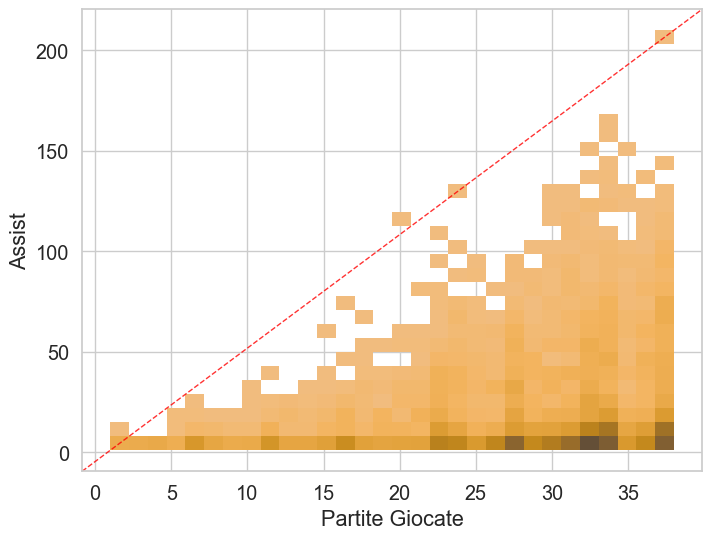

In [249]:
m = hbl_vga['Assist'] != 0
sns.histplot(data=hbl_vga[m], y='Assist', x='Partite Giocate', color=colori_soft[1], bins=30);
plt.axline([hbl_vga[m]['Partite Giocate'].min(), hbl_vga[m]['Assist'].min()],
           [hbl_vga[m]['Partite Giocate'].max(), hbl_vga[m]['Assist'].max()],
           color='red', alpha=0.8, linestyle='--', linewidth=1);

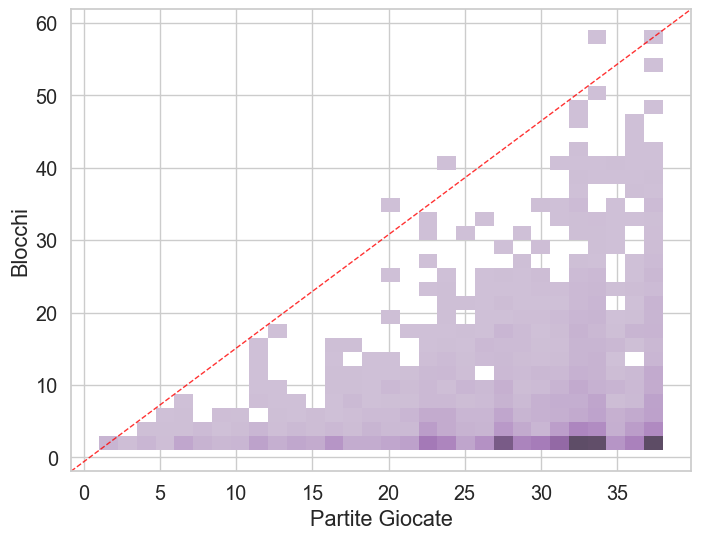

In [250]:
m = hbl_vga['Blocchi'] != 0
sns.histplot(data=hbl_vga[m], y='Blocchi', x='Partite Giocate', color=colori_soft[0], bins=30);
plt.axline([hbl_vga[m]['Partite Giocate'].min(), hbl_vga[m]['Blocchi'].min()],
           [hbl_vga[m]['Partite Giocate'].max(), hbl_vga[m]['Blocchi'].max()],
           color='red', alpha=0.8, linestyle='--', linewidth=1);

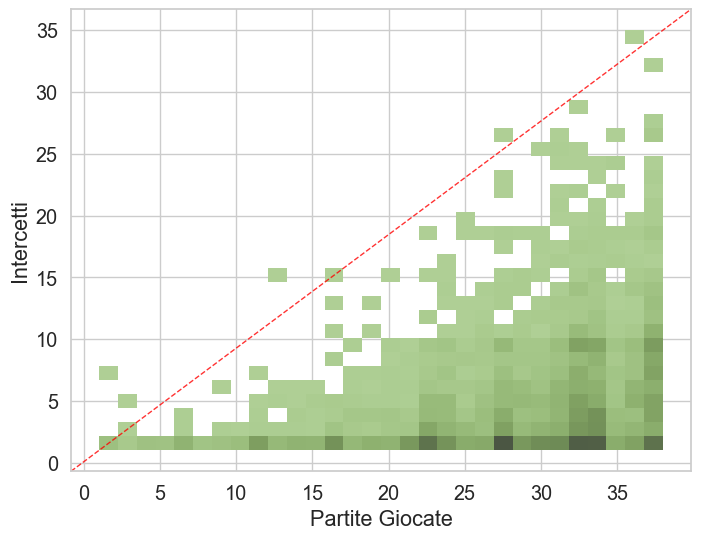

In [251]:
m = hbl_vga['Intercetti'] != 0
sns.histplot(data=hbl_vga[m], y='Intercetti', x='Partite Giocate', color=colori_soft[2], bins=30);
plt.axline([hbl_vga[m]['Partite Giocate'].min(), hbl_vga[m]['Intercetti'].min()],
           [hbl_vga[m]['Partite Giocate'].max(), hbl_vga[m]['Intercetti'].max()],
           color='red', alpha=0.8, linestyle='--', linewidth=1);

### FOCUS: FALLI E GOL PER SQUADRA

Verifichiamo per ogni squadra nelle varie stagioni (distinguiamo la categoria) considerate qual è la posizione che realizza più gol e quale quella che realizza più falli.

In [252]:
df1 = hbl.groupby(['Stagione', 'Categoria', 'Squadra', 'Posizione'])['Gol Totali'].max().reset_index()
df2 = hbl.groupby(['Stagione', 'Categoria', 'Squadra', 'Posizione'])['Falli Tecnici'].max().reset_index()

df1 = df1.loc[df1.groupby(['Stagione', 'Categoria', 'Squadra'])['Gol Totali'].idxmax()]
df2 = df2.loc[df2.groupby(['Stagione', 'Categoria', 'Squadra'])['Falli Tecnici'].idxmax()]

hbl_max = pd.concat([df1, df2])
display(hbl_max.head())
hbl_max.tail(5)

,Stagione,Categoria,Squadra,Posizione,Gol Totali,Falli Tecnici
0,17/18,A,BER,Ala Destra,169.0,NaN
8,17/18,A,FAG,Ala Sinistra,194.0,NaN
15,17/18,A,GUM,Ala Sinistra,138.0,NaN
26,17/18,A,GWD,Terzino Destro,151.0,NaN
29,17/18,A,HAN,Ala Sinistra,230.0,NaN


,Stagione,Categoria,Squadra,Posizione,Gol Totali,Falli Tecnici
1812,23/24,B,TUE,Terzino Sinistro,NaN,49.0
1818,23/24,B,TVG,Terzino Destro,NaN,65.0
1822,23/24,B,TVH,Centrale,NaN,65.0
1832,23/24,B,VFL,Terzino Destro,NaN,76.0
1836,23/24,B,VIN,Centrale,NaN,55.0


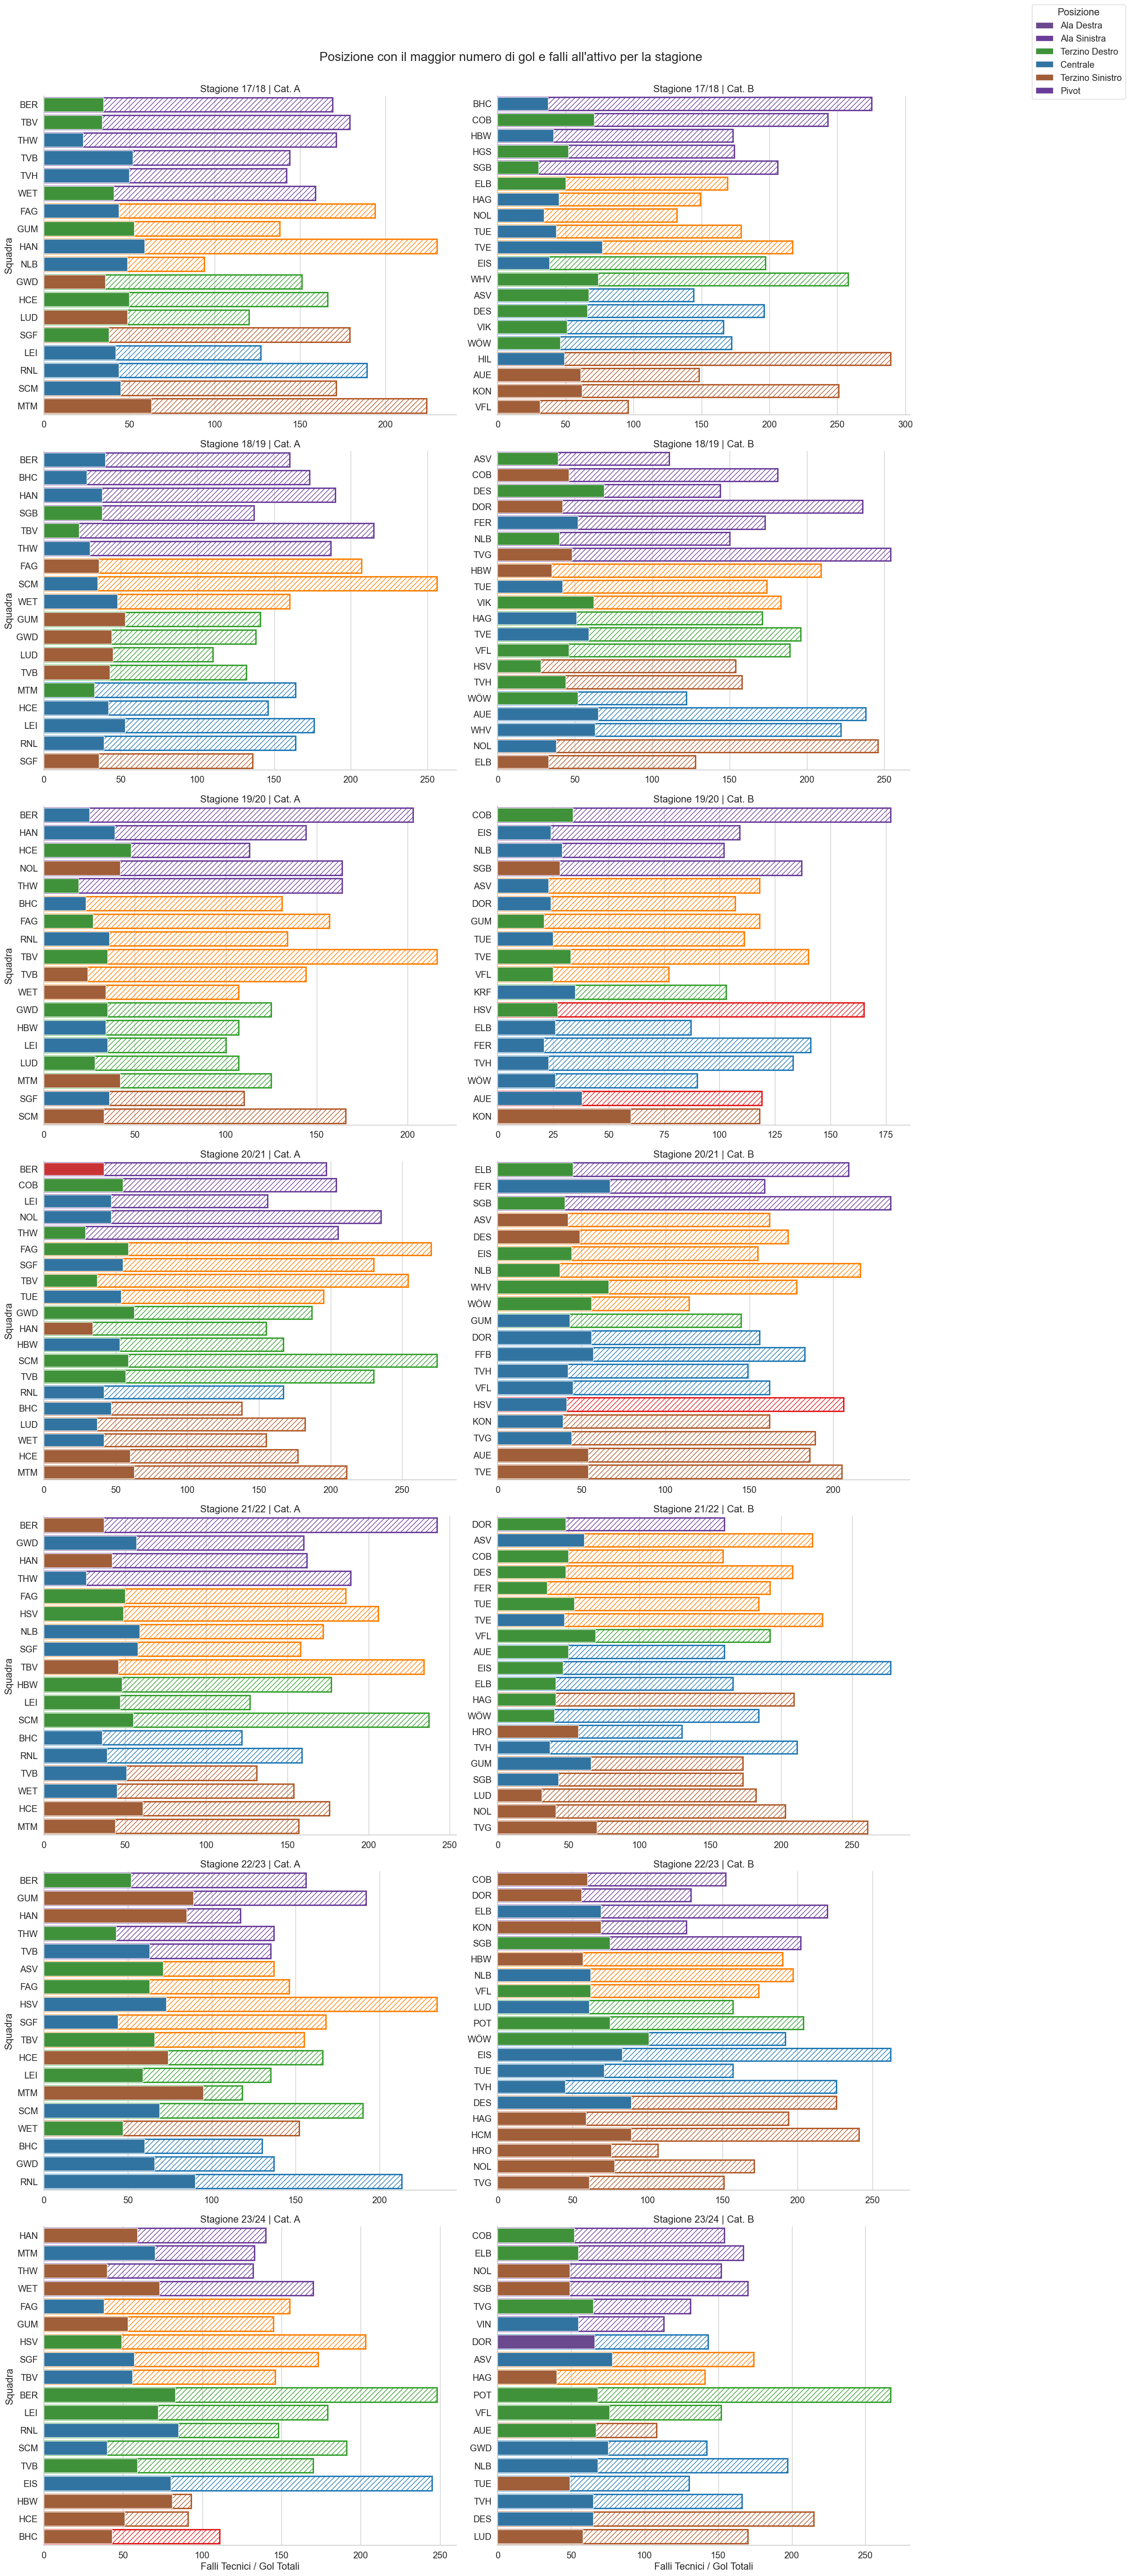

In [253]:
# ricreiamo l'ordine perchè potrebbero non esserci tutte le posizioni
posizioni = list(hbl_max['Posizione'].unique())
g = sns.FacetGrid( data= hbl_max, col='Categoria', row='Stagione', hue='Posizione', hue_order=posizioni,
                   sharex=False, sharey=False, height=8, aspect=1.3,);
g.map_dataframe(sns.barplot, 'Gol Totali', 'Squadra', fill=False, hatch='///', width=0.8);
g.map_dataframe(sns.barplot, 'Falli Tecnici', 'Squadra', width=0.8, legend=False);

# aggiunta titoli
g.set_titles(row_template='Stagione {row_name}', col_template='Cat. {col_name}')
g.set_axis_labels(x_var='Falli Tecnici / Gol Totali', y_var='Squadra', clear_inner=True);
g.fig.suptitle("Posizione con il maggior numero di gol e falli all'attivo per la stagione", y=1, fontsize=20)
g.add_legend(borderaxespad=0.2, alignment='center', title='Posizione');
sns.move_legend( g, loc='center left', bbox_to_anchor=(1, 1), ncol=1, frameon=True);
g.tight_layout();

<hr>

### FOCUS: PERCENTUALE REALIZZAZIONE

Risposta 1

Chi tira con più precisione?
- chi gioca di più (ha più partite giocate all'attivo)
- chi tira di più anche con meno partite all'attivo
- chi ha più esperienza (più stagioni giocate)

**ESTRAZIONE DEI DATI**

In [254]:
df_presenze = estrai_valori('Partite Giocate', 'sum', 50)
df_tiri = estrai_valori('Tiri Totali', 'sum', 50)
df_stagioni = estrai_valori('Stagione', 'count', 50)

display(df_presenze.head())
display(df_tiri.head())
display(df_stagioni.head())

,Categoria,Cognome,Nome,Partite Giocate,Percentuale Realizzazione
0,A,Mensah Larsen,Mads,229,0.545786
1,A,Kozina,Kresimir,228,0.746743
2,A,Rothlisberger,Samuel,227,0.718243
3,A,Bissel,Christopher,226,0.687500
4,A,Kneule,Tim,226,0.572214


,Categoria,Cognome,Nome,Tiri Totali,Percentuale Realizzazione
0,A,Schiller,Marcel,1834,0.716286
1,A,Hafner,Kai,1816,0.557029
2,A,Lindberg,Hans,1658,0.783786
3,A,Ekberg,Niclas,1544,0.766871
4,A,Damgaard,Michael,1541,0.558143


,Categoria,Cognome,Nome,Stagione,Percentuale Realizzazione
0,A,Bilyk,Nikola,7,0.506643
1,A,Binder,Lukas,7,0.698771
2,A,Bissel,Christopher,7,0.687500
3,A,Brozovic,Ilija,7,0.737429
4,A,Buchner,Vincent,7,0.613971


In [255]:
def perc_realizzazione_3plot(n=50) :
    # estrazione dati
    df_presenze = estrai_valori('Partite Giocate', 'sum', n)
    df_tiri = estrai_valori('Tiri Totali', 'sum', n)
    df_stagioni = estrai_valori('Stagione', 'count', n)
    
    # costruzione grafici
    fig, axes = plt.subplots(1, 3, figsize=(27, 9))
    # dizionario con i valori necessario per il grafico
    # { indice : [ dataframe, asse y = colonna, titolo] }
    valori = {0 : [df_presenze, 'Partite Giocate', "Giocatori con più partite all'attivo"],
              1 : [df_tiri, 'Tiri Totali', "Giocatori con più tiri"],
              2 : [df_stagioni, 'Stagione', "Giocatori con più stagioni all'attivo"]}
    
    for ax, v in zip(axes.ravel(), valori.keys()):
        sns.scatterplot(ax=ax, data=valori[v][0], x='Percentuale Realizzazione', y=valori[v][1], alpha=0.75,
                        hue='Categoria', style='Categoria', markers={'A':'^', 'B':'H'}, s=180, legend=False);
        ax.set_title(valori[v][2], fontsize=17, y=1.1)
        ax.axvline( x=0.5, color=colori_soft[5], linestyle='--', linewidth=3.5 );
    
    # Costruzione handles
    handles = [ mpl.lines.Line2D([],[],color=colori[0], marker='^', linestyle='None', markersize=15, label="A"),
                mpl.lines.Line2D([],[],color=colori[1], marker='H', linestyle='None', markersize=15, label="B")]
        
    # titolo, legenda
    fig.suptitle(f'Top {n} - Migliori Realizzatori delle 7 stagioni', fontsize=23, y=1);
    fig.legend(handles=handles, labels=Categorie, borderaxespad=0.2, alignment='center', loc='upper left', bbox_to_anchor=(1, 1),
               ncol=2, frameon=True, title='Categoria');
    plt.tight_layout();

In [256]:
def perc_realizzazione_1plot(n=50) :
    #estrazione dati
    df_presenze = estrai_valori('Partite Giocate', 'sum', n)
    df_tiri = estrai_valori('Tiri Totali', 'sum', n)
    df_stagioni = estrai_valori('Stagione', 'count', n)
    
    # costruzione grafico
    fig = plt.figure(figsize=(8,4))
    sns.scatterplot(data=df_presenze, x='Percentuale Realizzazione', y='Partite Giocate', color=colori_soft[2], label='Partite Giocate', legend=False);
    sns.scatterplot(data=df_tiri, x='Percentuale Realizzazione', y='Tiri Totali', color=colori_soft[3], label='Tiri Totali', legend=False); 
    plt.axvline( x=0.5, ymin=0, ymax=df_presenze['Partite Giocate'].max(), color=colori_soft[5], linestyle='--', linewidth=1.5 );
    fig.legend(borderaxespad=0.2, alignment='center', loc='upper left', bbox_to_anchor=(1, 0.9), ncol=1, frameon=True, title='Tipologia');
    fig.suptitle(f'Top {n} - Confronto tra partire e tiri', fontsize=17, y=1);
    plt.ylabel(None);

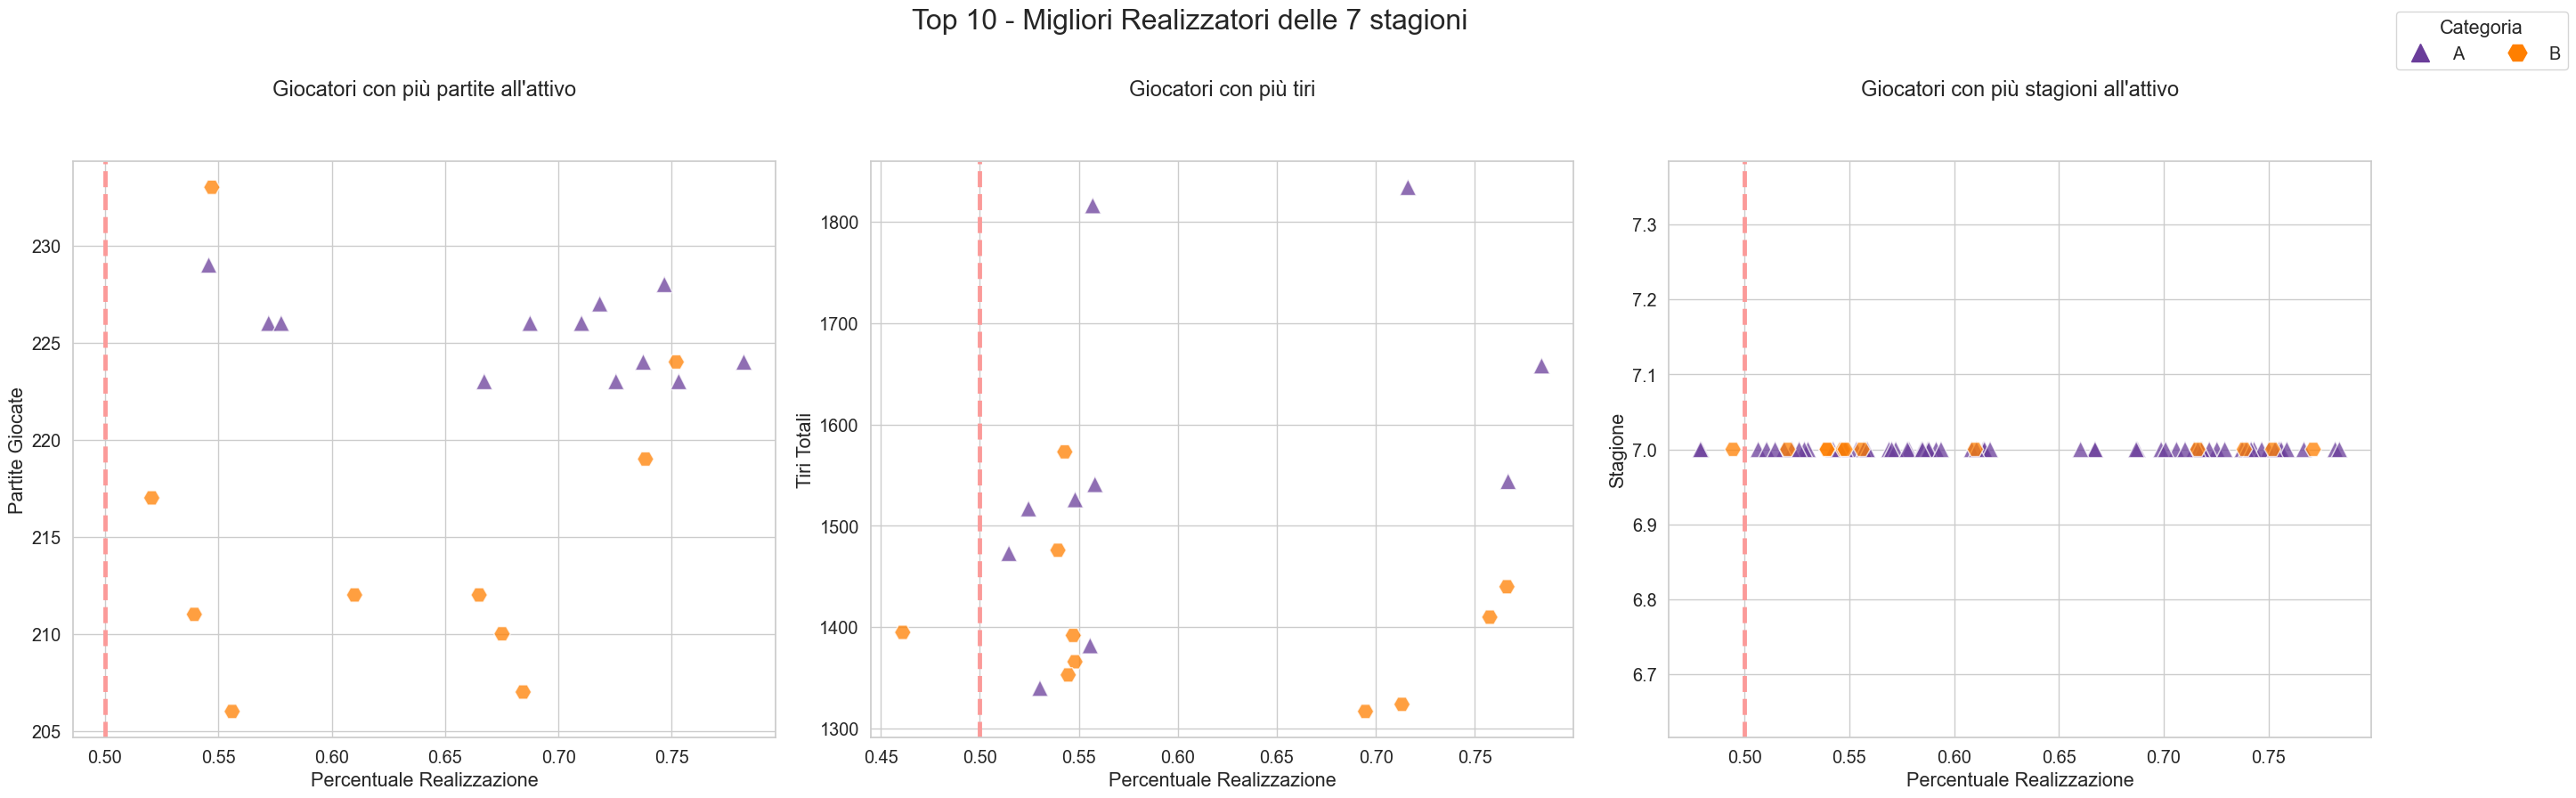

In [257]:
perc_realizzazione_3plot(10)

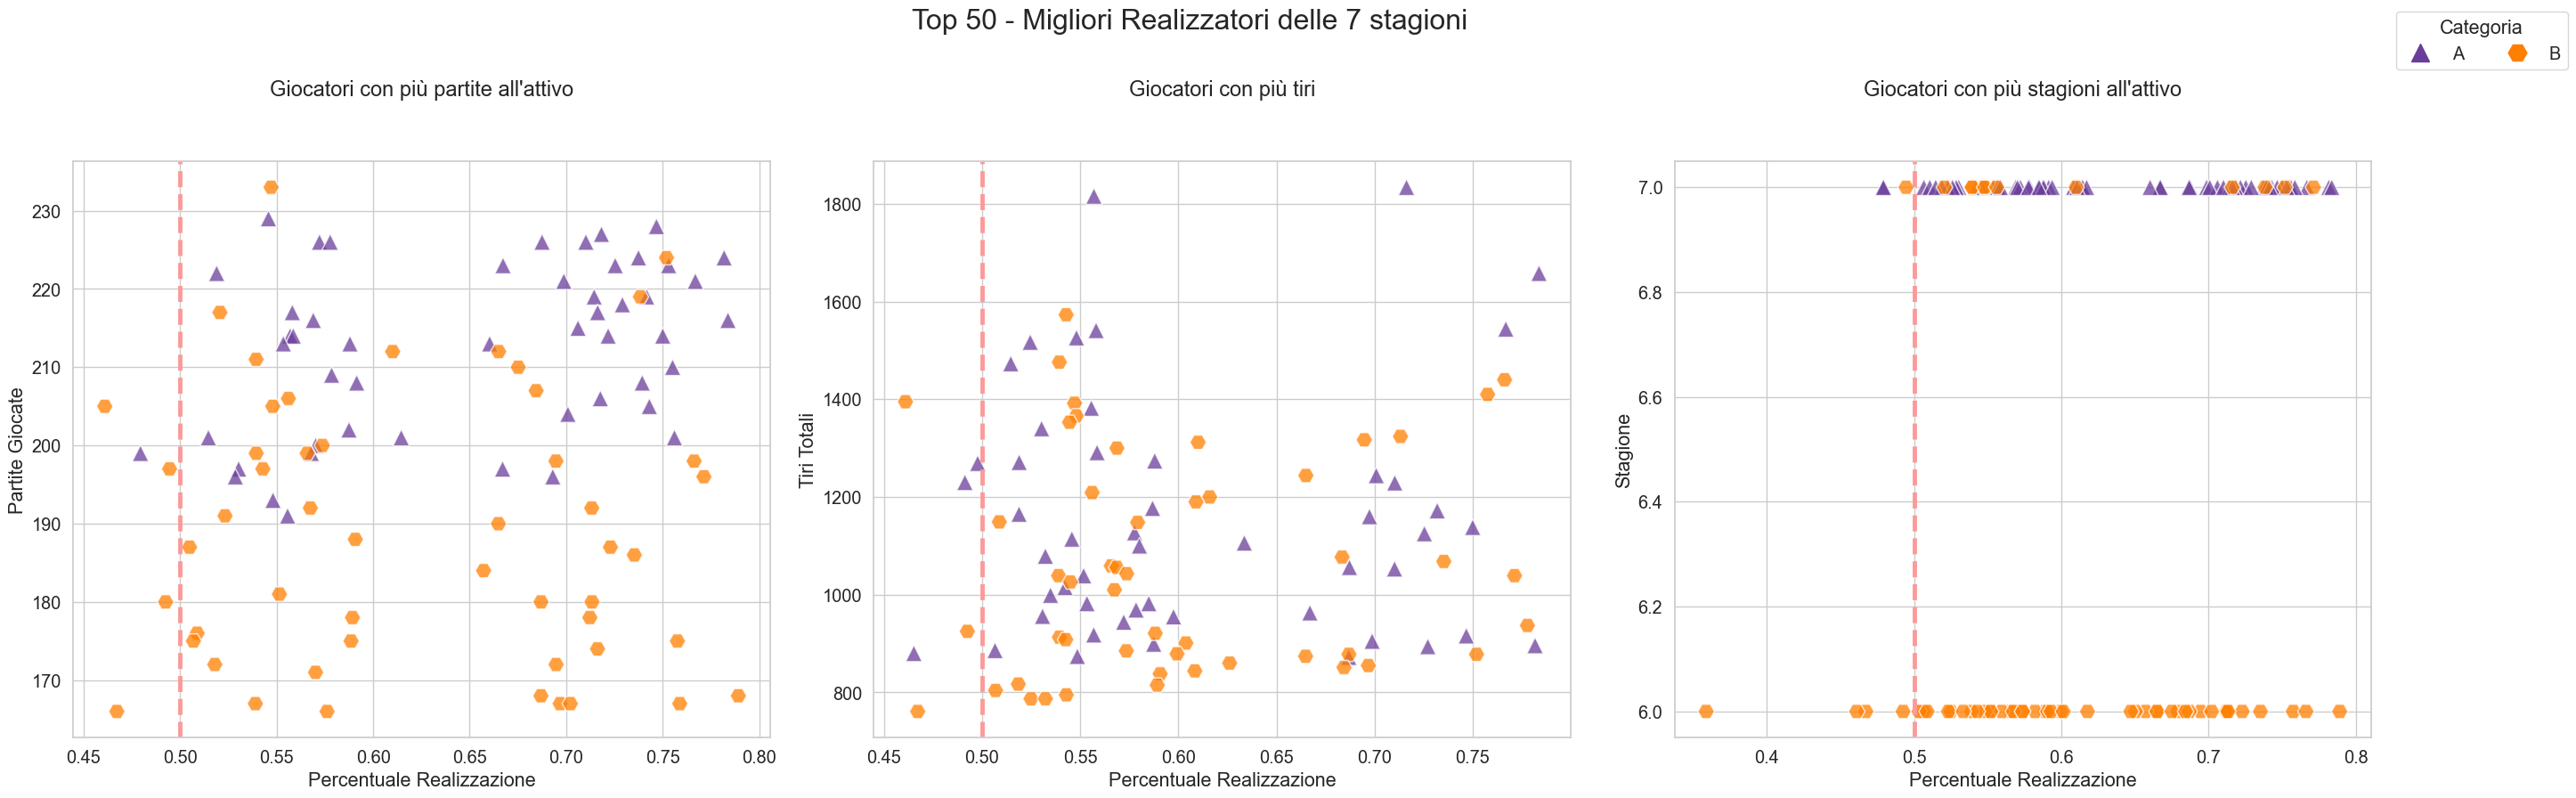

In [258]:
perc_realizzazione_3plot(50)

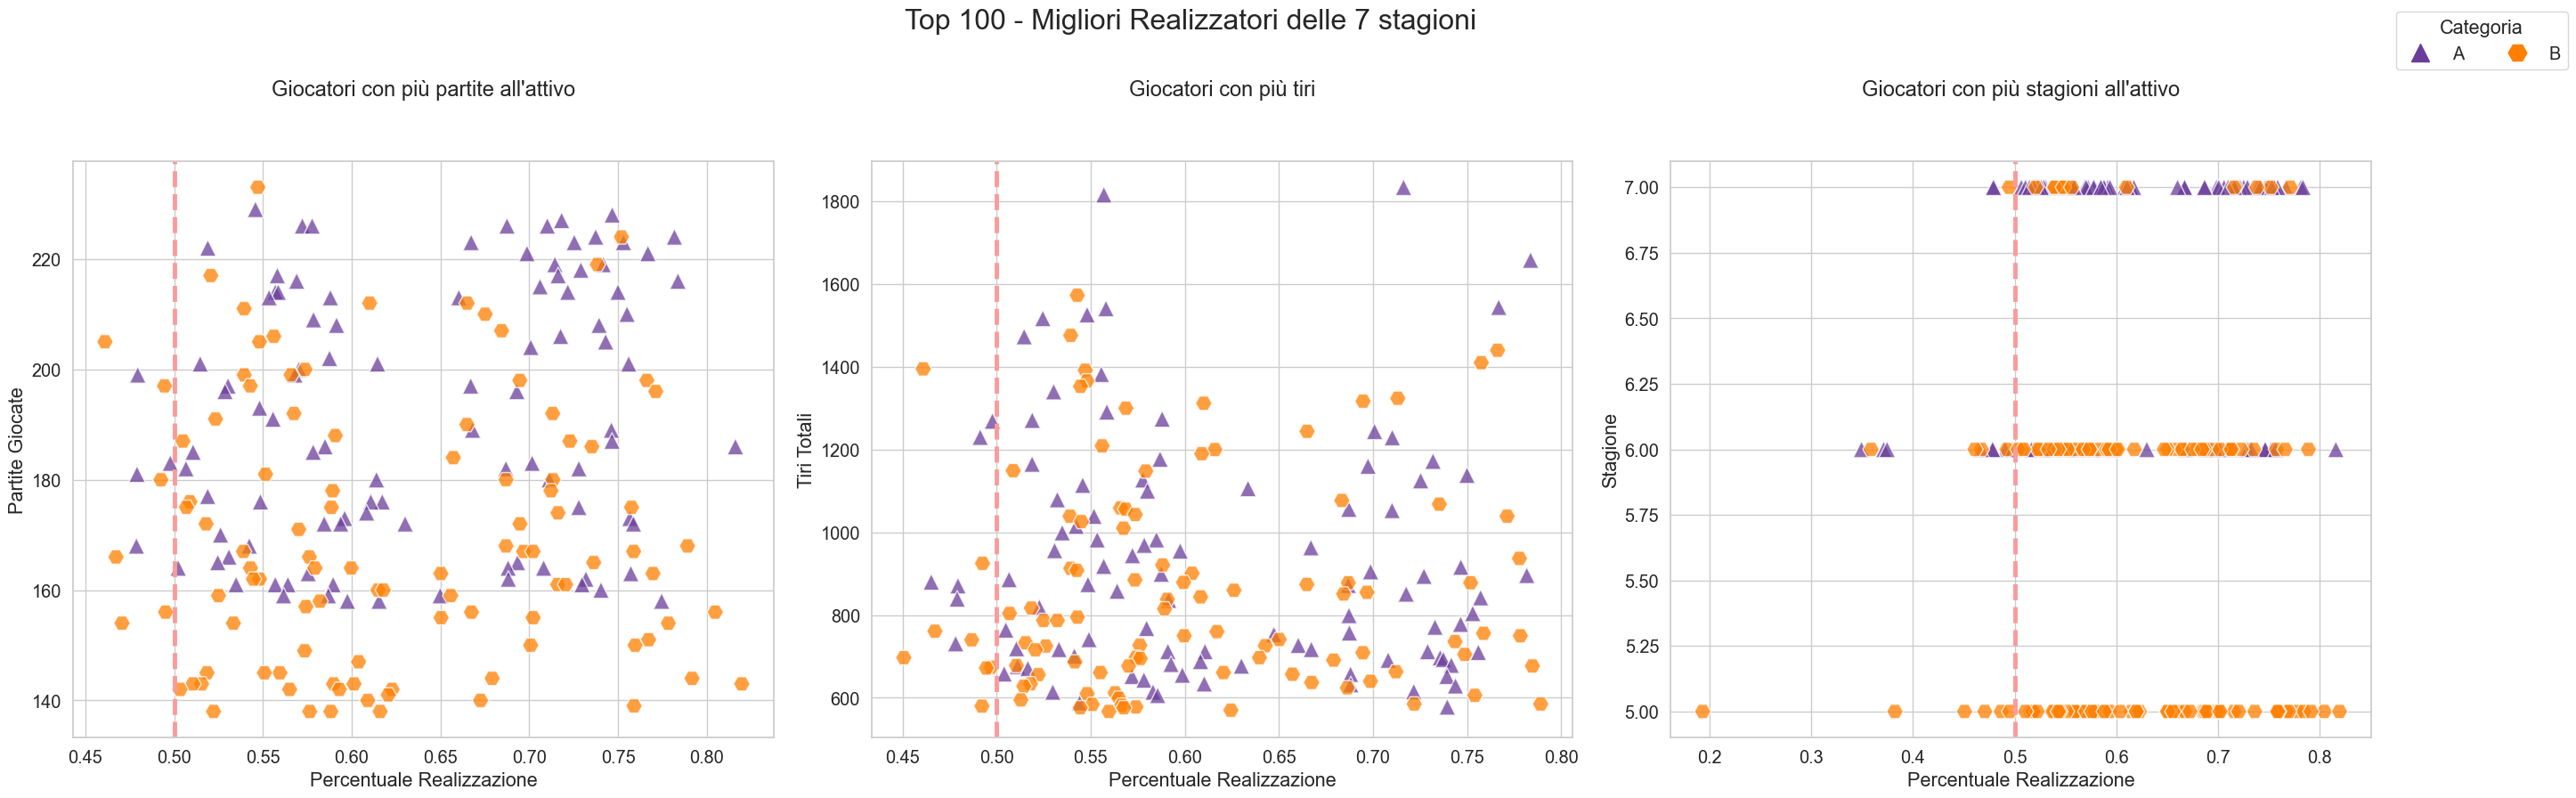

In [259]:
perc_realizzazione_3plot(100)

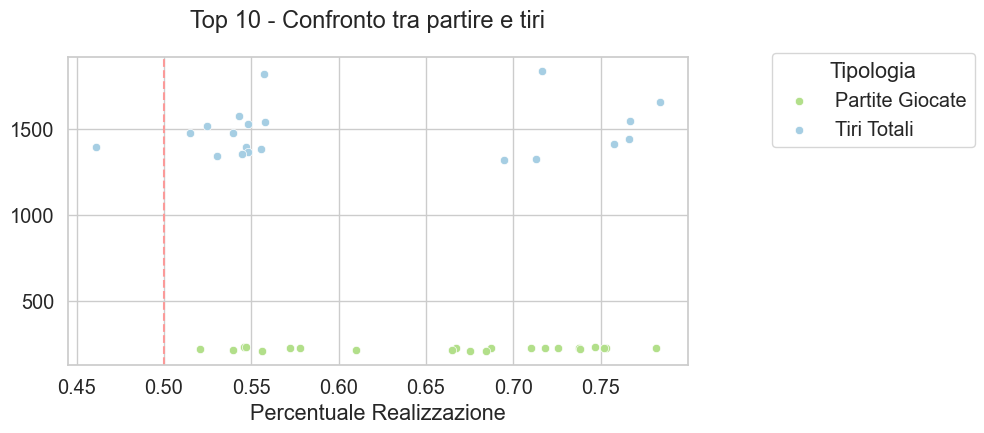

In [260]:
perc_realizzazione_1plot(10)

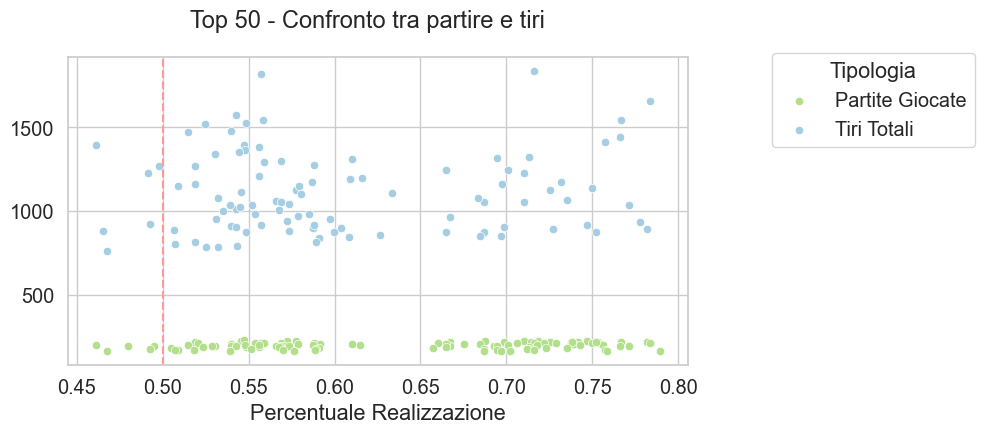

In [261]:
perc_realizzazione_1plot(50)

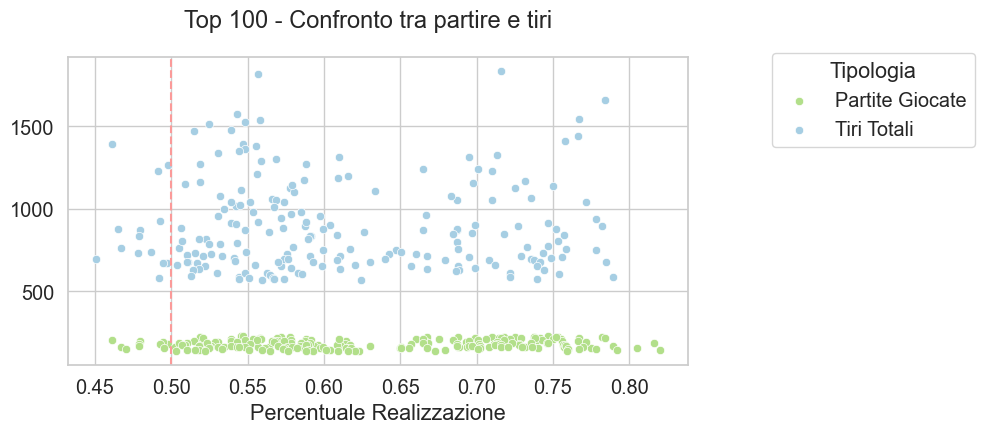

In [262]:
perc_realizzazione_1plot(100)

Cosa si osserva dai grafici:
* Notiamo che tra i top 50 non c'è nessuno che supera _0.80_, mentre tra i top 100 ci sono alcuni giocatori tra il gruppo di chi gioca di più.
* Tra i gruppi di chi gioca di più e chi tira di più la percentuale di realizzazione è distribuita in maniera abbastanza equa, non ci sono grandi differenze

<hr>

### FOCUS: ZONA DI TIRO

Risposta 2

Dividiamo il campo in tre zone [ fascia sx, fascia centrale, fascia dx ]

<img src="images/campo.png" width="600" height="337"></img>

- Quale zona tira più spesso?
- quale fa più gol?
- quale sbaglia di più?

Lo scopo della difesa è impedire il tiri o almeno intralciare l'azione dell'altra squadra.<br>
Questa punta a chiudere lo spazio al centro e lascia la possibilità del tiro alle fasce.<br>
Quindi ci si aspetta che la maggior parte dei tiri provengano dalle fasce.<br>

Però dal centro è più facile tirare, perché si ha una visuale migliore della porta mentre dalle fasce la visuale è ristretta.<br>
Inoltro dal centro c'è il pivot che gioca sulla linea dei 6 metri quindi è nella posizione migliore per tirare ma ha anche i difensori che lo tengono, quindi è più difficile passargli la palla.

**ESTRAZIONE DEI DATI**

Escludiamo i portieri perché tirano raramente e se lo fanno è un tiro porta a porta con la porta libera.<br>
Ed escludiamo i gol fatti con i tiri di rigore.

Dividiamo i dati dei giocatori in base alla posizione in cui giocano e sommiamo i <span class='code-exp'>'Gol Azione'</span> (non considerano i gol fatti tramite i rigori).<br>
Manteniamo le colonne <span class='code-exp'>'Categoria'</span>, <span class='code-exp'>'Tiri Totali'</span> e <span class='code-exp'>'Gol Azione'</span>.

In [263]:
# selezione e somma dei dati
df_fascia = hbl.groupby(['Categoria', 'Posizione'])[['Tiri Totali', 'Gol Azione', 'Tiri Sbagliati']].sum().reset_index()
# esclusione del portiere
df_fascia = df_fascia[ df_fascia['Posizione'] != 'Portiere']
# calcolo percentuale di realizzazione
df_fascia['Precisione'] = df_fascia['Gol Azione'] / df_fascia['Tiri Totali']

# mappatura fasce appartenenza
df_fascia['Fascia'] = np.select( [ df_fascia['Posizione'].str.contains('destr', case=False, na=False),
                                   df_fascia['Posizione'].str.contains('sinistr', case=False, na=False) ],
                                 [ 'Destra', 'Sinistra' ], default='Centro' )

df_fascia_bis = df_fascia.groupby(['Categoria', 'Fascia'])[['Tiri Totali', 'Gol Azione', 'Tiri Sbagliati']].sum().reset_index()
df_fascia_bis['Precisione'] = df_fascia_bis['Gol Azione'] / df_fascia_bis['Tiri Totali']
display(df_fascia, df_fascia_bis)

,Categoria,Posizione,Tiri Totali,Gol Azione,Tiri Sbagliati,Precisione,Fascia
0,A,Ala Destra,27047,14448,8043,0.534181,Destra
1,A,Ala Sinistra,26628,14274,7911,0.536052,Sinistra
2,A,Centrale,34887,18555,15046,0.531860,Centro
3,A,Pivot,23212,17008,6078,0.732724,Centro
5,A,Terzino Destro,37533,19143,16890,0.510031,Destra
6,A,Terzino Sinistro,40754,21410,18902,0.525347,Sinistra
7,B,Ala Destra,27997,15427,8818,0.551023,Destra
8,B,Ala Sinistra,29385,15450,9076,0.525778,Sinistra
9,B,Centrale,43818,22502,18381,0.513533,Centro
10,B,Pivot,24336,17517,6314,0.719798,Centro


,Categoria,Fascia,Tiri Totali,Gol Azione,Tiri Sbagliati,Precisione
0,A,Centro,58099,35563,21124,0.612110
1,A,Destra,64580,33591,24933,0.520146
2,A,Sinistra,67382,35684,26813,0.529578
3,B,Centro,68154,40019,24695,0.587185
4,B,Destra,67970,36437,26938,0.536075
5,B,Sinistra,75684,38952,30195,0.514666


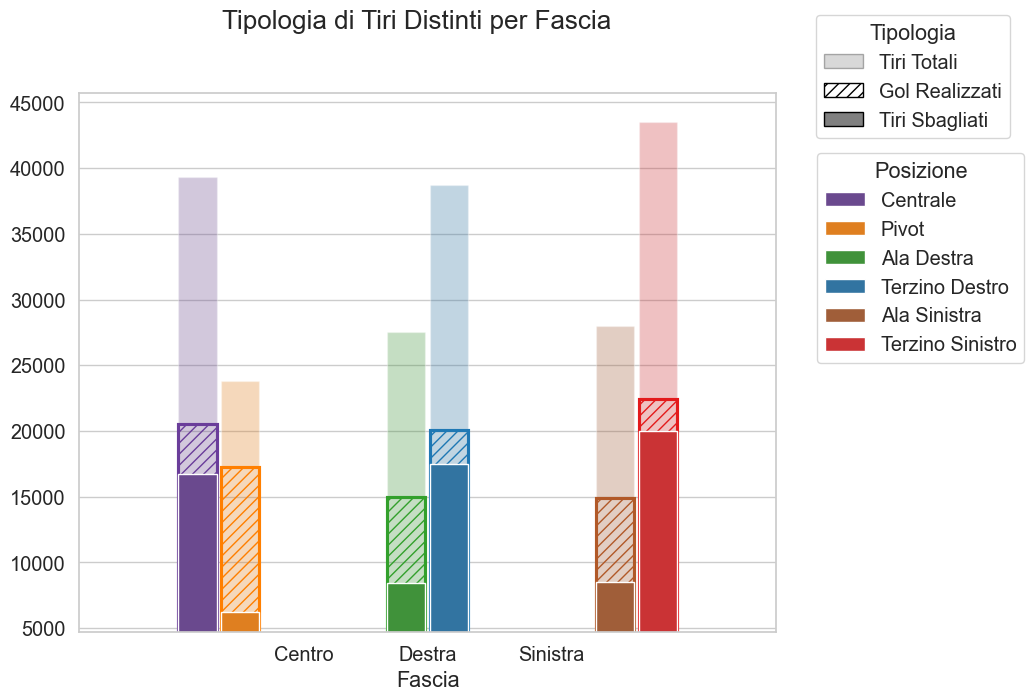

In [264]:
posizioni = df_fascia.groupby('Fascia')['Posizione'].unique().explode().tolist()
# kwargs in comune ai due grafici
parametri = {'hue':'Posizione', 'hue_order':posizioni, 'width':2.05, 'errorbar':None, 'order':Fasce, 'gap':0.1}

fig = plt.figure(figsize=(9,7))
sns.barplot(data=df_fascia, x='Fascia', y='Tiri Totali',  alpha=0.3, legend=None, **parametri);
sns.barplot(data=df_fascia, x='Fascia', y='Gol Azione',fill=False, hatch='///', legend=None, **parametri);
g = sns.barplot(data=df_fascia, x='Fascia', y='Tiri Sbagliati', **parametri);

# legenda delle posizioni
g.legend(title='Posizione', borderaxespad=0.3, alignment='center', loc='upper left', bbox_to_anchor=(1.05, 0.9), ncol=1, frameon=True);
# legenga tipologia
handles_tipologia = [ mpl.patches.Patch(facecolor="gray", edgecolor="black",  alpha=0.3, label="Tiri Totali"),
                      mpl.patches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Gol Realizzati"),
                      mpl.patches.Patch(facecolor="gray", edgecolor="black", label="Tiri Sbagliati") ]

fig.legend(handles=handles_tipologia, title="Tipologia", borderaxespad=0.3, alignment='center', loc="upper left", bbox_to_anchor=(0.937, 1), frameon=True);

# titolo e margini
fig.suptitle("Tipologia di Tiri Distinti per Fascia", y=1);
plt.ylabel(None)
plt.ylim(bottom=df_fascia['Tiri Sbagliati'].min() / 1.3);
plt.margins(x=0.2);

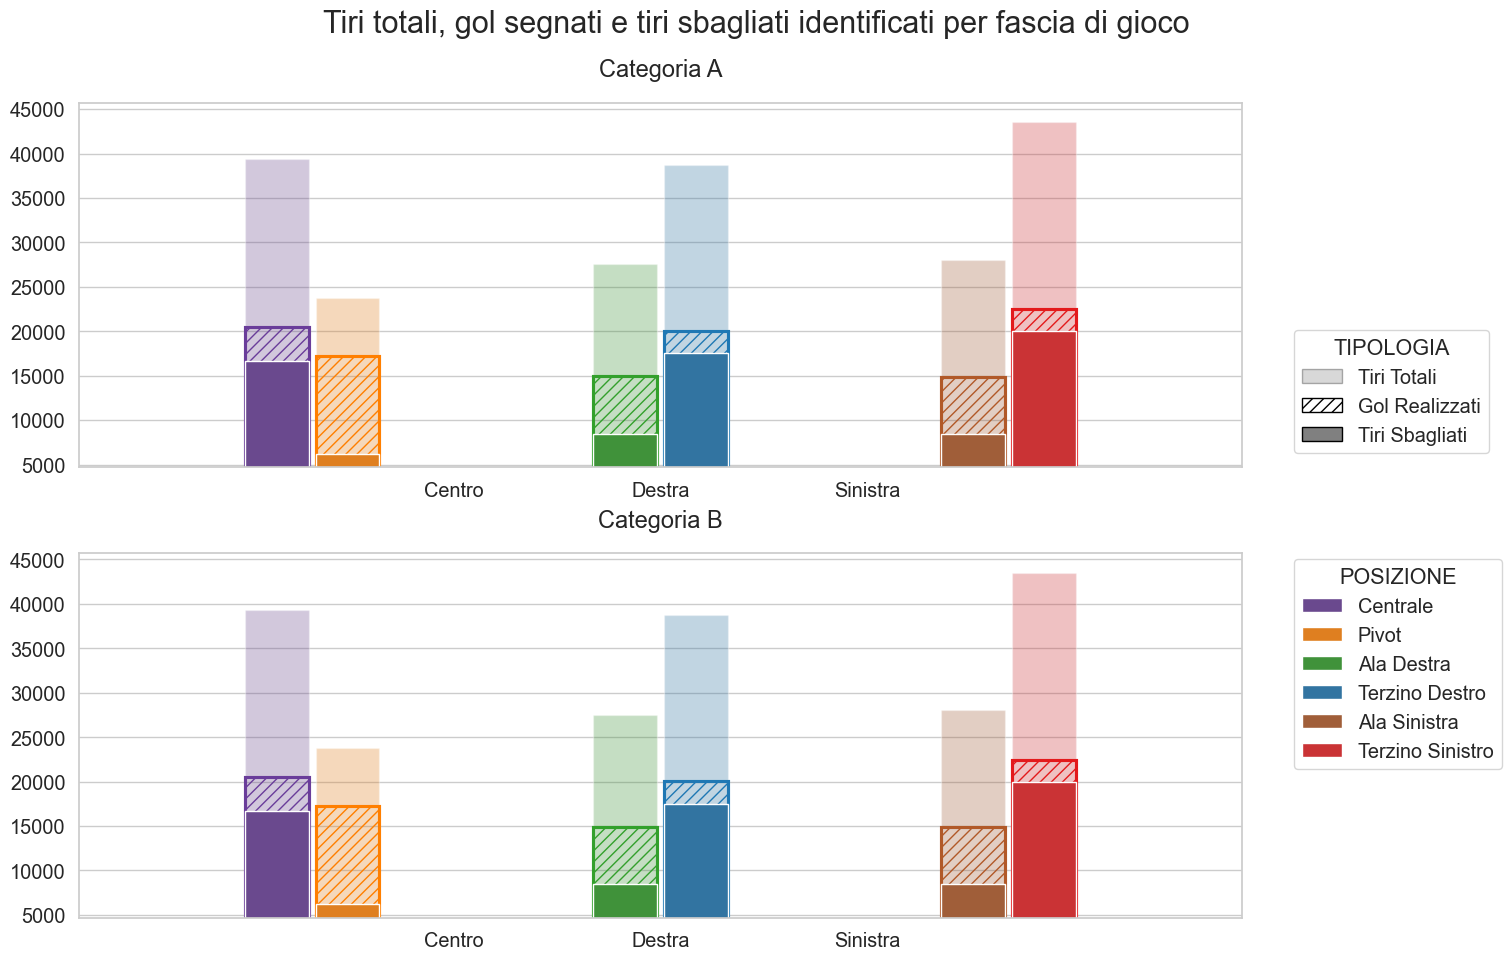

In [265]:
posizioni = df_fascia.groupby('Fascia')['Posizione'].unique().explode().tolist()
# kwargs in comune ai due grafici
parametri = {'hue':'Posizione', 'hue_order':posizioni, 'width':2.05, 'errorbar':None, 'order':Fasce, 'gap':0.1}
fig, axes = plt.subplots(2, 1, figsize=(15,9), sharex=False, sharey=False, squeeze=False, constrained_layout=True) 

# creazione di subplot in base alla categoria
for c, ax in zip( Categorie, axes.ravel() ):
    sns.barplot(ax=ax, data=df_fascia, x='Fascia', y='Tiri Totali', alpha=0.3,  legend=None, **parametri);
    sns.barplot(ax=ax, data=df_fascia, x='Fascia', y='Gol Azione',fill=False, hatch='///', legend=None, **parametri);
    g = sns.barplot(ax=ax, data=df_fascia, x='Fascia', y='Tiri Sbagliati', legend=(c=='B'), **parametri);
    ax.set_title(f'Categoria {c}', fontsize=17, y=1.05)
    ax.set_xlabel(None)
    ax.set_ylabel(None)
    ax.margins(x=0.2)
    ax.set_ylim(bottom=df_fascia['Tiri Sbagliati'].min() / 1.3);

g.legend(title='POSIZIONE', borderaxespad=0.3, alignment='center', loc='upper left', bbox_to_anchor=(1.04, 1), ncol=1, frameon=True);
# legenga tipologia
handles_tipologia = [ mpl.patches.Patch(facecolor="grey", edgecolor="black", alpha=0.3, label="Tiri Totali"),
                      mpl.patches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Gol Realizzati"),
                      mpl.patches.Patch(facecolor="gray", edgecolor="black", label="Tiri Sbagliati") ]

fig.legend(handles=handles_tipologia, title="TIPOLOGIA", borderaxespad=0.3, alignment='center', loc="upper left", bbox_to_anchor=(0.855, 0.7), frameon=True);
# titolo e margini
fig.suptitle("Tiri totali, gol segnati e tiri sbagliati identificati per fascia di gioco", y=1.05, fontsize=22);

<hr>

### FOCUS: PORTIERI

Risposta 3

In [266]:
df_portiere = hbl[ hbl['Posizione'] == 'Portiere' ]
df_portiere.head()

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
277,Rudeck,Christopher,BHC,Portiere,37,6,5,1,5,0,...,13,2,1,0,0,0,0,0,17/18,B
285,Klockmann,Dennis,VFL,Portiere,37,5,4,1,4,0,...,8,0,0,0,0,0,0,0,17/18,B
287,Buhrmester,Bjorn,NOL,Portiere,38,6,4,2,4,0,...,14,1,0,0,0,0,0,0,17/18,B
288,Brustmann,Max,WÖW,Portiere,37,10,4,6,4,0,...,11,4,1,0,0,5,0,0,17/18,B
293,Mrkva,Tomas,HBW,Portiere,30,5,3,2,3,0,...,7,2,1,0,0,0,0,0,17/18,B


Analizziamo i dati che abbiamo sui portieri.

Per ogni colonna del dataframe a partire da <span class='code-exp'>'Partite Giocate'</span>  fino a <span class='code-exp'>'Cartellino Blu'</span> verifichiamo quali e quanti dati diversi da 0 ci sono.

In [267]:
valori = df_portiere.columns.tolist()[df_portiere.columns.tolist().index('Partite Giocate'):-2]
for val in valori:
    df = df_portiere[df_portiere[val] != 0]
    print(str.upper(val))
    print(f'Righe con valori != 0 --> {df.shape[0]} / {df_portiere.shape[0]}')
    if df.shape[0] != 0:
        display(df[['Cognome','Nome','Squadra',val, 'Stagione','Categoria']].head())

PARTITE GIOCATE
Righe con valori != 0 --> 887 / 887


,Cognome,Nome,Squadra,Partite Giocate,Stagione,Categoria
277,Rudeck,Christopher,BHC,37,17/18,B
285,Klockmann,Dennis,VFL,37,17/18,B
287,Buhrmester,Bjorn,NOL,38,17/18,B
288,Brustmann,Max,WÖW,37,17/18,B
293,Mrkva,Tomas,HBW,30,17/18,B


TIRI TOTALI
Righe con valori != 0 --> 336 / 887


,Cognome,Nome,Squadra,Tiri Totali,Stagione,Categoria
277,Rudeck,Christopher,BHC,6,17/18,B
285,Klockmann,Dennis,VFL,5,17/18,B
287,Buhrmester,Bjorn,NOL,6,17/18,B
288,Brustmann,Max,WÖW,10,17/18,B
293,Mrkva,Tomas,HBW,5,17/18,B


GOL TOTALI
Righe con valori != 0 --> 336 / 887


...

2 MINUTI
Righe con valori != 0 --> 112 / 887


,Cognome,Nome,Squadra,2 Minuti,Stagione,Categoria
288,Brustmann,Max,WÖW,5,17/18,B
295,Schulz,Patrick,HGS,2,17/18,B
296,Bliss,Sebastian,TUE,1,17/18,B
316,Bozic,Vladimir,VIK,1,17/18,B
342,Huhnstock,Mario,ELB,2,17/18,B


CARTELLINO ROSSO
Righe con valori != 0 --> 13 / 887


,Cognome,Nome,Squadra,Cartellino Rosso,Stagione,Categoria
1112,Topfer,Erik,AUE,1,19/20,B
1484,Edvardsson,Aron Rafn,SGB,1,20/21,B
1502,Ambrosius,Philip,DES,1,20/21,B
1555,Broszinski,Jan Niklas,FER,1,20/21,B
1930,Topfer,Erik,AUE,1,21/22,B


CARTELLINO BLU
Righe con valori != 0 --> 0 / 887


Non sono segnate le parate che hanno fatto durante le stagioni, quindi ci concentriamo sugli <span class='code-exp'>'Assist'</span> che in questo caso sono considerati dei contropiedi, e consideriamo gli <span class='code-exp'>'Intercetti'</span> come i contropiedi impediti.

Un contropiede è un'azione veloce dopo una parata, una palla persa o un errore dell'attacco, dove la squadra in difesa recupera la palla e spesso il portiere lancia lungo per un giocatore che va al tiro da solo.

Un contropiede è più facile da lanciare che da intercettare.

In [268]:
df_intercetti = df_portiere[ df_portiere['Intercetti'] != 0 ]
df_assist = df_portiere[ df_portiere['Assist'] != 0 ]

display(df_intercetti.head(), df_assist.head());

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
277,Rudeck,Christopher,BHC,Portiere,37,6,5,1,5,0,...,13,2,1,0,0,0,0,0,17/18,B
288,Brustmann,Max,WÖW,Portiere,37,10,4,6,4,0,...,11,4,1,0,0,5,0,0,17/18,B
293,Mrkva,Tomas,HBW,Portiere,30,5,3,2,3,0,...,7,2,1,0,0,0,0,0,17/18,B
295,Schulz,Patrick,HGS,Portiere,36,6,3,3,3,0,...,10,2,3,0,2,2,0,0,17/18,B
298,Krechel,Oliver,COB,Portiere,34,4,3,1,3,0,...,10,4,1,0,0,0,0,0,17/18,B


,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Assist,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Stagione,Categoria
277,Rudeck,Christopher,BHC,Portiere,37,6,5,1,5,0,...,13,2,1,0,0,0,0,0,17/18,B
285,Klockmann,Dennis,VFL,Portiere,37,5,4,1,4,0,...,8,0,0,0,0,0,0,0,17/18,B
287,Buhrmester,Bjorn,NOL,Portiere,38,6,4,2,4,0,...,14,1,0,0,0,0,0,0,17/18,B
288,Brustmann,Max,WÖW,Portiere,37,10,4,6,4,0,...,11,4,1,0,0,5,0,0,17/18,B
293,Mrkva,Tomas,HBW,Portiere,30,5,3,2,3,0,...,7,2,1,0,0,0,0,0,17/18,B


Analisi <span class='code-exp'>'Assist'</span>

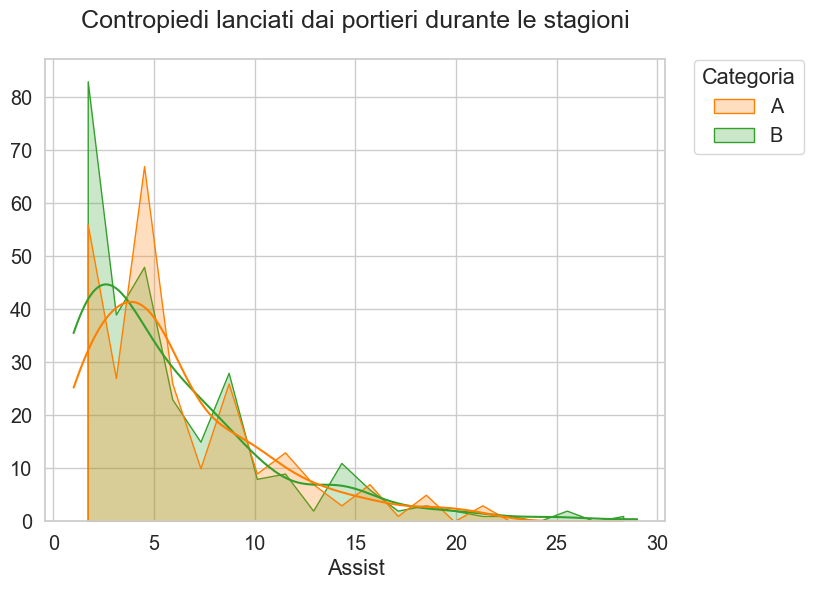

In [269]:
g = sns.histplot(df_assist, x='Assist', hue='Categoria', hue_order=Categorie, multiple='layer',element='poly', kde=True, palette=sns.color_palette(colori_strong[1:3]));
plt.ylabel(None)
sns.move_legend(g, borderaxespad=0.5, alignment='center', loc="upper left", bbox_to_anchor=(1.03, 1.02), frameon=True);
# titolo e margini
plt.title('Contropiedi lanciati dai portieri durante le stagioni', y=1.05, fontsize=18);

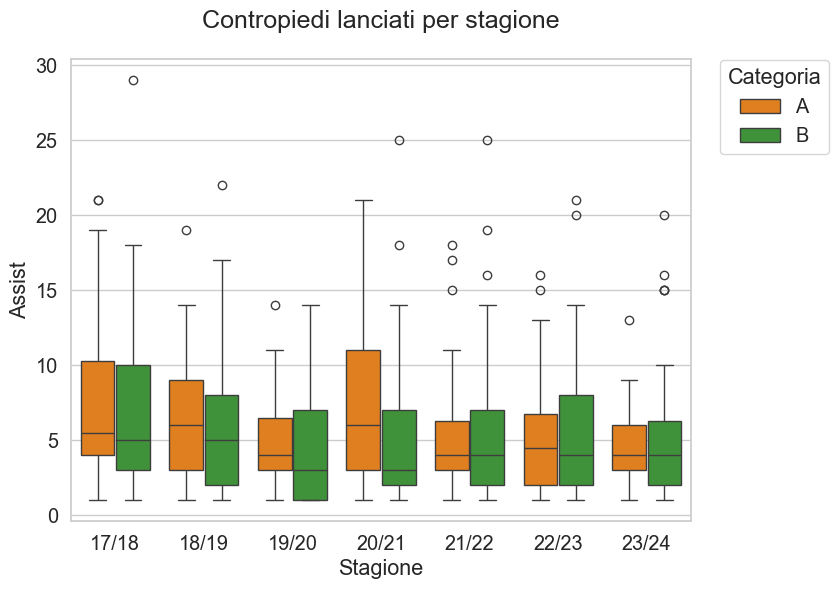

In [270]:
g = sns.boxplot(df_assist, y='Assist', x='Stagione', hue='Categoria', hue_order=Categorie, gap=0.05, palette=sns.color_palette(colori_strong[1:3]));
#plt.ylabel(None)
sns.move_legend(g, borderaxespad=0.5, alignment='center', loc="upper left", bbox_to_anchor=(1.03, 1.02), frameon=True);
# titolo e margini
plt.title('Contropiedi lanciati per stagione', y=1.05, fontsize=18);

Suddividiamo in tre gruppi in base al numero di stagioni che sono state giocate dai portieri (meno di 2, tra 2 e 4, più di 4).

In [271]:
# conteggio stagioni e associazione al portiere
count_stagioni = df_assist.groupby(['Cognome', 'Nome', 'Categoria'])['Stagione'].count().reset_index()
df_assist_bis = pd.merge(df_assist.drop(columns='Stagione'), count_stagioni, how='left', on=['Cognome', 'Nome', 'Categoria'])

# divisione in intervalli
bins = [0, 2, 4, 7] # valore di fine intervallo
categorie = ['< 2', '2-4', '> 4' ]

# applicare categorie al df
df_assist_bis['Bin Stagione'] = pd.cut(df_assist_bis['Stagione'], bins=bins, labels=categorie, right=True)
df_assist_bis

,Cognome,Nome,Squadra,Posizione,Partite Giocate,Tiri Totali,Gol Totali,Tiri Sbagliati,Gol Azione,Gol Rigore,...,Falli Tecnici,Intercetti,Blocchi,Cartellino Giallo,2 Minuti,Cartellino Rosso,Cartellino Blu,Categoria,Stagione,Bin Stagione
0,Rudeck,Christopher,BHC,Portiere,37,6,5,1,5,0,...,2,1,0,0,0,0,0,B,1.0,< 2
1,Klockmann,Dennis,VFL,Portiere,37,5,4,1,4,0,...,0,0,0,0,0,0,0,B,6.0,> 4
2,Buhrmester,Bjorn,NOL,Portiere,38,6,4,2,4,0,...,1,0,0,0,0,0,0,B,5.0,> 4
3,Brustmann,Max,WÖW,Portiere,37,10,4,6,4,0,...,4,1,0,0,5,0,0,B,3.0,2-4
4,Mrkva,Tomas,HBW,Portiere,30,5,3,2,3,0,...,2,1,0,0,0,0,0,B,2.0,< 2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,Saeveraas,Kristian,LEI,Portiere,28,0,0,0,0,0,...,1,0,0,0,0,0,0,A,4.0,2-4
540,Ruminsky,Mario,HBW,Portiere,28,0,0,0,0,0,...,2,0,0,0,0,0,0,A,4.0,2-4
541,Suljakovic,Anadin,WET,Portiere,25,0,0,0,0,0,...,0,0,0,0,0,0,0,A,2.0,< 2
542,Obling,Bertram,HCE,Portiere,31,0,0,0,0,0,...,1,0,0,0,0,0,0,A,2.0,< 2


<Figure size 1400x1200 with 0 Axes>

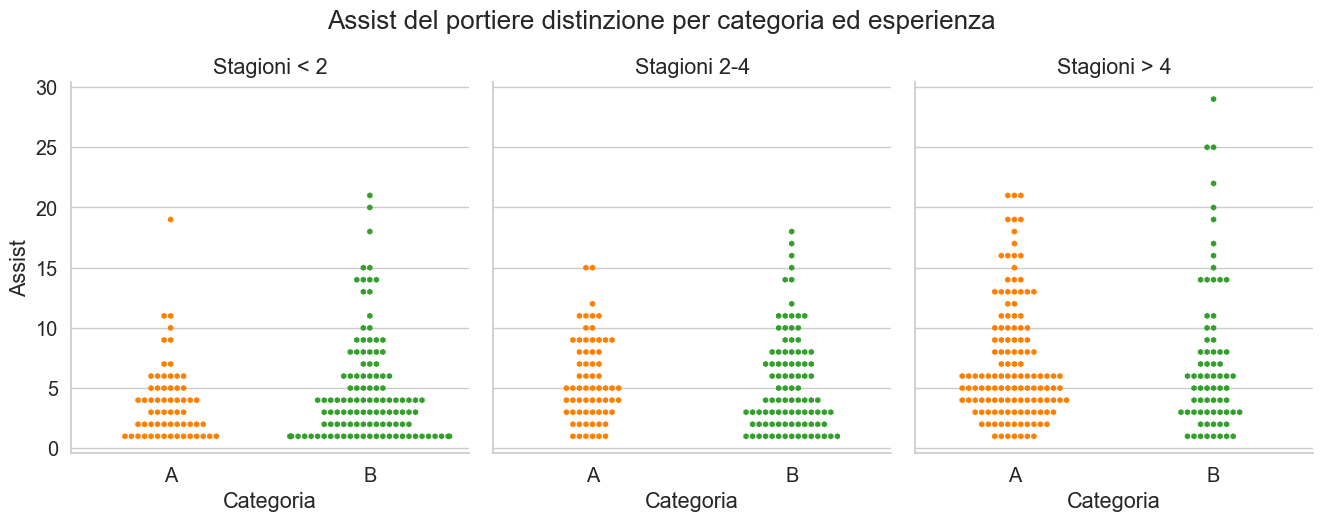

In [272]:
fig = plt.figure(figsize=(14,12));
g = sns.catplot(data=df_assist_bis, kind="swarm", x="Categoria", y="Assist", col="Bin Stagione", hue="Categoria", hue_order=Categorie,
                order=Categorie, aspect=0.9, marker='h', s=20, palette=sns.color_palette(colori_strong[1:3]) );
g.set_titles( col_template='Stagioni {col_name}');
g.fig.suptitle('Assist del portiere distinzione per categoria ed esperienza', y=1.05);

Analisi <span class='code-exp'>'Intercetti'</span>

In [273]:
df_intercetti[['Cognome', 'Squadra', 'Intercetti']]

,Cognome,Squadra,Intercetti
277,Rudeck,BHC,1
288,Brustmann,WÖW,1
293,Mrkva,HBW,1
295,Schulz,HGS,3
298,Krechel,COB,1
...,...,...,...
5671,Portner,SCM,1
5695,Simic,MTM,3
5728,Heinevetter,TVB,1
5742,Ebner,LEI,1


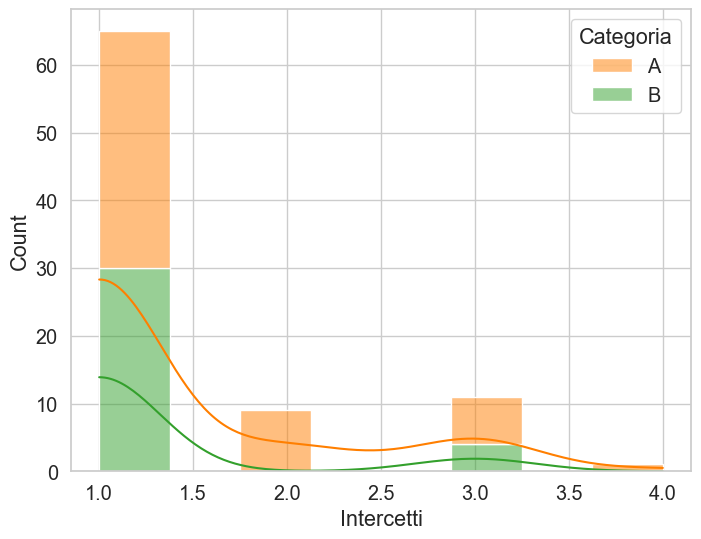

In [274]:
sns.histplot(df_intercetti, x='Intercetti', hue='Categoria', hue_order=Categorie,
             multiple='stack', element='bars', kde=True, palette=sns.color_palette(colori_strong[1:3]));
fig.suptitle('Intercetti dei portierinelle stagioni');

In [275]:
plt.close()